# 1. Setup
This section is for importing packages, configuring settings, and loading the dataset.

In [11]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from scipy.stats import chi2_contingency, spearmanr
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

# Notebook display settings
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Load raw dataset
data_path = "/Users/clairesng/Downloads/capstone_divorced/divorced.csv"
df = pd.read_csv(data_path, encoding="latin1")

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Loaded: 120 rows × 28 columns


,Timestamp,What is your current marital status?,Wife: How old were you at marriage? (in years),Husband: How old were you at marriage? (in years),Our Family Backgrounds:,Have you been married before?,Was buying a home or moving out a significant factor for marriage?,How did you meet?,How long was your relationship before marriage?,Did you attend Premarital Counselling?,Did you live together before marriage?,What were your views on marriage prior to the wedding?,"Do you believe in ""Soulmates"" or ""The One""?",Our views on religion:,Do you have children together?,What were your views on children?,On political views:,Relationship with In-laws is best described as: (Select Neutral if Not Applicable) [You and your in-laws],Relationship with In-laws is best described as: (Select Neutral if Not Applicable) [Your spouse/ex and their in-laws],Our household is primarily:,On managing household finances:,What best describes your personalities?,Do you share a key common interest?,Do you approve of each other's social circle?,How do you feel about pets & pet ownership?,Which top 3 values do you prioritise most in your life? [Me],Which top 3 values do you prioritise most in your life? [My spouse/ex],"Thank you for reaching the end! \n\nIf there are there any other factors you feel are important for a relationship that were not mentioned, feel free to add them here. Otherwise, press submit!"
0,2/12/2026 18:58:26,Divorced or Annulled,25,27,Both our parents are Divorced,No,No,Mutual friends,6 monthsâ1 year,No,Yes,Both wanted marriage,Half - one of us does,Different beliefs but accepting,Yes,Both wanted children,We have different views but respect them,Bad,Bad,Dual income,"Half aligned, half in disagreement",Mixed - One of each,No,Somewhat,We are both indifferent or do not want pets,"Self-Improvement, Health and Fitness, Community","Career Ambition, Family, Security/Stability",NaN
1,2/13/2026 20:30:11,Married or Widowed,25,26,Both our parents are Married,No,No,Family introduction,<6 months,No,No,Both wanted marriage,Half - one of us does,Same beliefs but different practices,Yes,Both wanted children,We share the same views,Good,Bad,Single income,Mostly aligned,Both Introverts,Yes,Yes,"Mixed - One of us love pets, the other does not","Career Ambition, Family, Security/Stability","Family, Security/Stability, Health and Fitness",\nHow is your sex life? How well do you commu...
2,2/14/2026 13:50:01,Married or Widowed,41,41,Both our parents are Divorced,No,Yes,Online (e.g. Dating App),4+ years,Yes,No,Ambivalent,Half - one of us does,Same beliefs but different practices,No,Both ambivalent or undecided,We share the same views,Neutral,Neutral,Single income,"Half aligned, half in disagreement",Mixed - One of each,Yes,Somewhat,We are both indifferent or do not want pets,"Family, Faith and Spirituality, Security/Stabi...","Career Ambition, Adventure/Trying New Things, ...",NaN
3,2/14/2026 16:47:29,Married or Widowed,36,33,Both our parents are Married,No,No,Mutual friends,2â4 years,No,Yes,Ambivalent,Half - one of us does,Different beliefs but accepting,Yes,Both ambivalent or undecided,We share the same views,Very Good,Very Good,Dual income,Mostly aligned,Mixed - One of each,Yes,Yes,We both love and/or own pets,"Career Ambition, Family, Adventure/Trying New ...","Career Ambition, Family, Self-Improvement",NaN
4,2/14/2026 17:53:13,Married or Widowed,25,26,Both our parents are Married,No,No,Met in USA,4+ years,No,No,Both wanted marriage,Yes - we both do,Different beliefs but accepting,Yes,Both wanted children,We both avoid discussing politics,Good,Good,Dual income,Mostly aligned,Mixed - One of each,No,Yes,We are both indifferent or do not want pets,"Career Ambition, Family, Faith and Spirituality","Career Ambition, Family, Faith and Spirituality",NaN


# 2. Divorced Modelling Notebook
This notebook builds and compares predictive models for marital outcome (`Married/Widowed` vs `Divorced/Annulled`).

> Workflow summary
1. Load raw survey data
2. Recreate key cleaning and engineered features from EDA
3. Train multiple model runs with different feature sets
4. Compare performance and overfitting behavior
5. Interpret model behavior with SHAP explanations

In [12]:
# --- Age cleaning: replicate divorced_eda logic ---
wife_age_col = "Wife: How old were you at marriage? (in years)"
husband_age_col = "Husband: How old were you at marriage? (in years)"

# 1) Standardise obvious text-null tokens to NaN
null_tokens = {
    "": np.nan, " ": np.nan, "na": np.nan, "n/a": np.nan, "nan": np.nan,
    "none": np.nan, "null": np.nan, "-": np.nan
}
for c in [wife_age_col, husband_age_col]:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace(null_tokens)
    )

# 2) Extract numeric part only (e.g., "40 yrs" -> 40)
for c in [wife_age_col, husband_age_col]:
    df[c] = df[c].str.extract(r"(\d+)", expand=False)
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) Flag unrealistic values (same rule used in EDA: age <= 10)
bad_wife = (df[wife_age_col] <= 10).fillna(False)
bad_husband = (df[husband_age_col] <= 10).fillna(False)

print("Rows with suspicious ages (<=10):", int((bad_wife | bad_husband).sum()))

df.loc[bad_wife, wife_age_col] = np.nan
df.loc[bad_husband, husband_age_col] = np.nan

# 4) Impute missing with column medians
wife_median = df[wife_age_col].median()
husband_median = df[husband_age_col].median()

df[wife_age_col] = df[wife_age_col].fillna(wife_median)
df[husband_age_col] = df[husband_age_col].fillna(husband_median)

# 5) Cast to integer
df[wife_age_col] = df[wife_age_col].round().astype(int)
df[husband_age_col] = df[husband_age_col].round().astype(int)

print(f"Wife median used: {wife_median}")
print(f"Husband median used: {husband_median}")
print("Remaining nulls:",
      {wife_age_col: int(df[wife_age_col].isna().sum()),
       husband_age_col: int(df[husband_age_col].isna().sum())})

display(df[[wife_age_col, husband_age_col]].describe().T)

Rows with suspicious ages (<=10): 1
Wife median used: 28.0
Husband median used: 29.0
Remaining nulls: {'Wife: How old were you at marriage? (in years)': 0, 'Husband: How old were you at marriage? (in years)': 0}


,count,mean,std,min,25%,50%,75%,max
Wife: How old were you at marriage? (in years),120.0,27.591667,4.376207,19.0,25.0,28.0,30.25,41.0
Husband: How old were you at marriage? (in years),120.0,29.700000,4.251742,20.0,27.0,29.0,32.00,42.0


# 3. Data preparation

### 3.1 Data cleaning: age fields
This section standardises age-at-marriage fields for husband and wife.

What is done:
- Removes text noise and extracts numeric age values
- Treats unrealistic entries as missing
- Imputes missing values with column medians
- Produces clean integer ages for downstream modelling

In [13]:
# --- Feature: age_gap (husband - wife) ---
df["age_gap"] = df[husband_age_col] - df[wife_age_col]

print("Created column: age_gap = husband_age - wife_age")
display(df[[wife_age_col, husband_age_col, "age_gap"]].head(10))
print(df["age_gap"].describe().round(2))

Created column: age_gap = husband_age - wife_age


,Wife: How old were you at marriage? (in years),Husband: How old were you at marriage? (in years),age_gap
0,25,27,2
1,25,26,1
2,41,41,0
3,36,33,-3
4,25,26,1
5,27,27,0
6,25,26,1
7,30,30,0
8,33,29,-4
9,25,27,2


count    120.00
mean       2.11
std        2.20
min       -4.00
25%        1.00
50%        2.00
75%        3.00
max       12.00
Name: age_gap, dtype: float64


In [14]:
# --- Repeat EDA cleaning: How did you meet? ---
meet_col = 'How did you meet?'

meet_mapping = {
    # Standard options
    'School': 'School',
    'Workplace': 'Workplace',
    'Mutual friends': 'Mutual Friends',
    'Online (e.g. Dating App)': 'Dating App / Online',
    'Religious Place of Worship': 'Religious Community',
    'Family introduction': 'Family Introduction',

    # Free-text "Other" responses
    'At an event': 'Social / Event',
    'Cc events ': 'Social / Event',
    'Club': 'Social / Event',
    'Clubbing': 'Social / Event',
    'Social gathering by chance': 'Social / Event',
    'Distance relative': 'Family Introduction',
    'Met in USA': 'Other',
    'On a plane': 'Other',
    'only my wife and I know how we met.  Not something we have shared.': 'Other',
}

df['meet_clean'] = df[meet_col].map(meet_mapping)

unmapped_meet = df[df['meet_clean'].isna() & df[meet_col].notna()]
print(f"Unmapped meet responses: {len(unmapped_meet)}")
if len(unmapped_meet):
    display(unmapped_meet[[meet_col]].drop_duplicates())

# --- Repeat EDA cleaning: What were your views on children? ---
views_child_col = 'What were your views on children?'

views_child_mapping = {
    'Both wanted children': 'Both wanted children',
    "Both didn't want children": "Both didn't want children",
    'Mixed - One spouse wanted children': 'Mixed views',
    'Both ambivalent or undecided': 'Both ambivalent or undecided',
    'Too old': "Both didn't want children",
}

df[views_child_col] = df[views_child_col].map(views_child_mapping)

print("\nCleaned meet categories:")
print(df['meet_clean'].value_counts(dropna=False).to_string())

print("\nCleaned views on children categories:")
print(df[views_child_col].value_counts(dropna=False).to_string())

Unmapped meet responses: 0

Cleaned meet categories:
meet_clean
Workplace              28
School                 25
Mutual Friends         21
Dating App / Online    17
Social / Event         10
Family Introduction     9
Religious Community     7
Other                   3

Cleaned views on children categories:
What were your views on children?
Both wanted children            61
Both didn't want children       22
Mixed views                     21
Both ambivalent or undecided    16


In [15]:
# --- Recreate values overlap features (from divorced_eda) ---
me_col = "Which top 3 values do you prioritise most in your life? [Me]"
spouse_col = "Which top 3 values do you prioritise most in your life? [My spouse/ex]"

def split_by_comma(text):
    if pd.isna(text):
        return []
    vals = [x.strip().lower() for x in str(text).split(",") if x.strip()]
    # deduplicate while preserving order
    out = []
    for v in vals:
        if v not in out:
            out.append(v)
    return out

me_sets = df[me_col].apply(lambda x: set(split_by_comma(x)))
spouse_sets = df[spouse_col].apply(lambda x: set(split_by_comma(x)))

df["values_overlap_count"] = [len(a & b) for a, b in zip(me_sets, spouse_sets)]

df["overlap_0"] = (df["values_overlap_count"] == 0).astype(int)
df["overlap_1"] = (df["values_overlap_count"] == 1).astype(int)
df["overlap_2"] = (df["values_overlap_count"] == 2).astype(int)
df["overlap_3"] = (df["values_overlap_count"] >= 3).astype(int)  # use == 3 if exact only

# sanity checks
print("Overlap distribution:")
print(df["values_overlap_count"].value_counts(dropna=False).sort_index().to_string())

row_bucket_sum = df[["overlap_0", "overlap_1", "overlap_2", "overlap_3"]].sum(axis=1)
print("Rows not in exactly one overlap bucket:", int((row_bucket_sum != 1).sum()))

display(
    df[[me_col, spouse_col, "values_overlap_count", "overlap_0", "overlap_1", "overlap_2", "overlap_3"]].head(10)
)

Overlap distribution:
values_overlap_count
0    20
1    41
2    39
3    17
4     2
6     1
Rows not in exactly one overlap bucket: 0


,Which top 3 values do you prioritise most in your life? [Me],Which top 3 values do you prioritise most in your life? [My spouse/ex],values_overlap_count,overlap_0,overlap_1,overlap_2,overlap_3
0,"Self-Improvement, Health and Fitness, Community","Career Ambition, Family, Security/Stability",0,1,0,0,0
1,"Career Ambition, Family, Security/Stability","Family, Security/Stability, Health and Fitness",2,0,0,1,0
2,"Family, Faith and Spirituality, Security/Stabi...","Career Ambition, Adventure/Trying New Things, ...",0,1,0,0,0
3,"Career Ambition, Family, Adventure/Trying New ...","Career Ambition, Family, Self-Improvement",2,0,0,1,0
4,"Career Ambition, Family, Faith and Spirituality","Career Ambition, Family, Faith and Spirituality",3,0,0,0,1
5,"Career Ambition, Family, Security/Stability","Family, Adventure/Trying New Things, Travel",1,0,1,0,0
6,"Career Ambition, Family, Health and Fitness","Career Ambition, Family, Health and Fitness",3,0,0,0,1
7,"Family, Faith and Spirituality, Adventure/Tryi...","Career Ambition, Faith and Spirituality, Self-...",1,0,1,0,0
8,Faith and Spirituality,Career Ambition,0,1,0,0,0
9,"Career Ambition, Family, Adventure/Trying New ...","Career Ambition, Family, Adventure/Trying New ...",4,0,0,0,1


In [16]:
# Analysing in-law relationship features
# Source columns (used only to build combined features)
inlaw_you_col = 'Relationship with In-laws is best described as: (Select Neutral if Not Applicable) [You and your in-laws]'
inlaw_spouse_col = 'Relationship with In-laws is best described as: (Select Neutral if Not Applicable) [Your spouse/ex and their in-laws]'

status_col = 'What is your current marital status?'
rel_length_col = 'How long was your relationship before marriage?'
children_col = 'Do you have children together?'

# --- build combined features only ---
scale = {'Very Bad': 1, 'Bad': 2, 'Neutral': 3, 'Good': 4, 'Very Good': 5}

for c in [inlaw_you_col, inlaw_spouse_col]:
    df[c] = df[c].astype(str).str.strip()

df['inlaw_mean_score'] = df[[inlaw_you_col, inlaw_spouse_col]].replace('nan', np.nan).apply(
    lambda r: np.nanmean([scale.get(r[inlaw_you_col], np.nan), scale.get(r[inlaw_spouse_col], np.nan)]),
    axis=1
)
df['inlaw_min_score'] = df[[inlaw_you_col, inlaw_spouse_col]].replace('nan', np.nan).apply(
    lambda r: np.nanmin([scale.get(r[inlaw_you_col], np.nan), scale.get(r[inlaw_spouse_col], np.nan)]),
    axis=1
)
df['inlaw_gap_score'] = df[[inlaw_you_col, inlaw_spouse_col]].replace('nan', np.nan).apply(
    lambda r: abs(scale.get(r[inlaw_you_col], np.nan) - scale.get(r[inlaw_spouse_col], np.nan)),
    axis=1
)

df['inlaw_joint_cat'] = df[inlaw_you_col] + ' | ' + df[inlaw_spouse_col]

df['inlaw_mean_band'] = pd.cut(
    df['inlaw_mean_score'], bins=[0, 2.5, 3.5, 5],
    labels=['Low', 'Neutral', 'High'], include_lowest=True
)
df['inlaw_min_band'] = pd.cut(
    df['inlaw_min_score'], bins=[0, 2.5, 3.5, 5],
    labels=['Low', 'Neutral', 'High'], include_lowest=True
)
df['inlaw_gap_band'] = pd.cut(
    df['inlaw_gap_score'], bins=[-0.1, 0.1, 1.1, 5],
    labels=['Aligned (0)', 'Slight mismatch (1)', 'Large mismatch (2+)'], include_lowest=True
)

df['inlaw_pair_profile'] = np.select(
    [
        (df['inlaw_mean_score'] >= 4) & (df['inlaw_min_score'] >= 4),
        (df['inlaw_mean_score'] <= 2) & (df['inlaw_min_score'] <= 2),
        (df['inlaw_gap_score'] >= 2),
    ],
    ['Both positive', 'Both strained', 'Large mismatch'],
    default='Mixed/neutral'
)

combined_inlaw_features = [
    'inlaw_joint_cat',
    'inlaw_mean_band',
    'inlaw_min_band',
    'inlaw_gap_band',
    'inlaw_pair_profile'
]

def chi2_assoc(data, feature, target):
    sub = data[[feature, target]].dropna()
    ct = pd.crosstab(sub[target], sub[feature])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return {'Feature': feature, 'Target': target, 'Chi2': np.nan, 'p-value': np.nan, "Cramér's V": np.nan}
    chi2, p, _, expected = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    return {
        'Feature': feature, 'Target': target, 'Chi2': round(chi2, 3), 'p-value': round(p, 4),
        "Cramér's V": round(v, 3), 'Low expected (<5)': '⚠️' if (expected < 5).any() else ''
    }

# A) marital status
status_results_combined = pd.DataFrame(
    [chi2_assoc(df, f, status_col) for f in combined_inlaw_features]
).sort_values(["Cramér's V", "p-value"], ascending=[False, True])

# B) secondary targets
secondary_results_combined = pd.DataFrame(
    [chi2_assoc(df, f, t) for f in combined_inlaw_features for t in [rel_length_col, children_col]]
).sort_values(["Target", "Cramér's V", "p-value"], ascending=[True, False, True])

display(status_results_combined)
display(secondary_results_combined)

# Optional: keep only combined features for modeling input
#X_inlaw_combined = df[combined_inlaw_features].copy()


,Feature,Target,Chi2,p-value,Cramér's V,Low expected (<5)
0,inlaw_joint_cat,What is your current marital status?,64.180,0.0000,0.731,⚠️
2,inlaw_min_band,What is your current marital status?,50.315,0.0000,0.648,
4,inlaw_pair_profile,What is your current marital status?,48.312,0.0000,0.635,
1,inlaw_mean_band,What is your current marital status?,47.736,0.0000,0.631,
3,inlaw_gap_band,What is your current marital status?,12.995,0.0015,0.329,


,Feature,Target,Chi2,p-value,Cramér's V,Low expected (<5)
1,inlaw_joint_cat,Do you have children together?,19.963,0.4602,0.408,⚠️
9,inlaw_pair_profile,Do you have children together?,4.001,0.2613,0.183,⚠️
3,inlaw_mean_band,Do you have children together?,3.659,0.1605,0.175,
5,inlaw_min_band,Do you have children together?,2.558,0.2783,0.146,
7,inlaw_gap_band,Do you have children together?,0.528,0.7678,0.066,
0,inlaw_joint_cat,How long was your relationship before marriage?,84.131,0.3543,0.419,⚠️
4,inlaw_min_band,How long was your relationship before marriage?,20.866,0.0075,0.295,⚠️
2,inlaw_mean_band,How long was your relationship before marriage?,16.420,0.0368,0.262,⚠️
8,inlaw_pair_profile,How long was your relationship before marriage?,18.988,0.0888,0.230,⚠️
6,inlaw_gap_band,How long was your relationship before marriage?,3.394,0.9072,0.119,⚠️


### 3.2 Feature engineering recap before modelling
We recreated key engineered features used in exploratory data analysis:
- `age_gap`
- `meet_clean`
- cleaned views on children
- value alignment features (`values_overlap_count`, overlap indicators)
- combined in-law features (e.g., `inlaw_min_band`, `inlaw_joint_cat`)

> The next sections run multiple model configurations (Run 1, Run 2, ...), each changing the feature set to test impact on predictive performance.

# 4. Modelling runs

In [17]:
# Run 1 of Modelling: Wife age, Husband age, Age gap, Family backgrounds, Married before, Buying home/moving out, How did you meet, Length of relationship before marriage, Premarital Counselling, Live together before marriage, Views on Marriage, Belief in Soulmates, Religious beliefs, Views on Children, Political views, in_law_min_band, Income Type of household, Financial alignment, Personality Mix (I/E), Key common interest, Approve of social circle, Pets, Values overlap count.

### 4.1 Run 1: Baseline large feature set
This run establishes a broad baseline using the larger curated feature set.

Interpretation goals:
- Compare train vs test metrics to check overfitting
- Identify strongest model family for this initial feature mix
- Produce aggregate feature importance to guide first round of feature pruning

In [18]:
# Optional model imports
HAS_LGBM, HAS_XGB, HAS_CAT = True, True, True
try:
    from lightgbm import LGBMClassifier
except Exception:
    HAS_LGBM = False

try:
    from xgboost import XGBClassifier
except Exception:
    HAS_XGB = False

try:
    from catboost import CatBoostClassifier
except Exception:
    HAS_CAT = False

# -----------------------------
# 1) Feature set for Run 1
# -----------------------------
target_col = "What is your current marital status?"
target_map = {"Married or Widowed": 0, "Divorced or Annulled": 1}

feature_cols = [
    wife_age_col,  # cleaned age
    husband_age_col,  # cleaned age
    "age_gap",
    "Our Family Backgrounds:",
    "Have you been married before?",
    "Was buying a home or moving out a significant factor for marriage?",
    "meet_clean",  # cleaned meet feature
    "How long was your relationship before marriage?",
    "Did you attend Premarital Counselling?",
    "Did you live together before marriage?",
    "What were your views on marriage prior to the wedding?",
    'Do you believe in "Soulmates" or "The One"?',
    "Our views on religion:",
    "What were your views on children?",  # cleaned views on children
    "On political views:",
    "inlaw_min_band",  # combined in-law feature only
    "Our household is primarily:",
    "On managing household finances:",
    "What best describes your personalities?",
    "Do you share a key common interest?",
    "Do you approve of each other's social circle?",
    "How do you feel about pets & pet ownership?",
    "values_overlap_count"
]

missing = [c for c in feature_cols + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

data = df[feature_cols + [target_col]].copy()
data = data[data[target_col].isin(target_map)].copy()

X = data[feature_cols]
y = data[target_col].map(target_map).astype(int)

# numeric vs categorical
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in feature_cols if c not in numeric_features]

# -----------------------------
# 2) Train/test split + preprocess
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
feature_names_t = preprocessor.get_feature_names_out()

# -----------------------------
# 3) Models
# -----------------------------
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, class_weight="balanced", random_state=42
    ),
}

if HAS_LGBM:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        random_state=42, verbosity=-1
    )

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=42
    )

if HAS_CAT:
    models["CatBoost"] = CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        loss_function="Logloss", verbose=0, random_seed=42
    )

# -----------------------------
# 4) Fit/evaluate + importances
# -----------------------------
results = []
importance_long = []

def model_importance(model, model_name, feat_names):
    if hasattr(model, "coef_"):
        imp = np.abs(model.coef_).ravel()
    elif hasattr(model, "feature_importances_"):
        imp = np.asarray(model.feature_importances_, dtype=float).ravel()
    else:
        return pd.DataFrame(columns=["model", "feature_transformed", "importance"])
    if imp.sum() > 0:
        imp = imp / imp.sum()
    return pd.DataFrame({
        "model": model_name,
        "feature_transformed": feat_names,
        "importance": imp
    })

for name, model in models.items():
    # CatBoost fallback to dense if sparse is not accepted
    if name == "CatBoost":
        Xtr = X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t
        Xte = X_test_t.toarray() if hasattr(X_test_t, "toarray") else X_test_t
        model.fit(Xtr, y_train)
        pred_train = model.predict(Xtr)
        pred_test = model.predict(Xte)
    else:
        model.fit(X_train_t, y_train)
        pred_train = model.predict(X_train_t)
        pred_test = model.predict(X_test_t)

    train_acc = accuracy_score(y_train, pred_train)
    test_acc = accuracy_score(y_test, pred_test)
    test_f1 = f1_score(y_test, pred_test)

    results.append({
        "model": name,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "test_f1": round(test_f1, 4),
        "overfit_gap(train-test)": round(train_acc - test_acc, 4)
    })

    imp_df = model_importance(model, name, feature_names_t)
    importance_long.append(imp_df)

    print(f"\n=== {name} ===")
    print(f"Train acc: {train_acc:.4f} | Test acc: {test_acc:.4f} | Test F1: {test_f1:.4f}")
    print(classification_report(y_test, pred_test, target_names=["Married/Widowed", "Divorced/Annulled"]))

results_df = pd.DataFrame(results).sort_values(
    ["test_accuracy", "test_f1"], ascending=False
).reset_index(drop=True)

print("\n=== Model comparison (ranked) ===")
display(results_df)

best_model_row = results_df.iloc[0]
print(
    f"Best by test accuracy: {best_model_row['model']} "
    f"(test_acc={best_model_row['test_accuracy']:.4f}, test_f1={best_model_row['test_f1']:.4f})"
)

# -----------------------------
# 5) Aggregate transformed importance -> original feature
# -----------------------------
if importance_long:
    imp_all = pd.concat(importance_long, ignore_index=True)

    cat_cols_sorted = sorted(categorical_features, key=len, reverse=True)

    def to_base_feature(transformed_name: str) -> str:
        if transformed_name.startswith("num__"):
            return transformed_name.replace("num__", "", 1)
        if transformed_name.startswith("cat__"):
            body = transformed_name.replace("cat__", "", 1)
            for c in cat_cols_sorted:
                prefix = c + "_"
                if body == c or body.startswith(prefix):
                    return c
            return body
        return transformed_name

    imp_all["feature"] = imp_all["feature_transformed"].apply(to_base_feature)

    imp_feature_model = (
        imp_all.groupby(["model", "feature"], as_index=False)["importance"]
        .sum()
    )

    imp_wide = (
        imp_feature_model.pivot(index="feature", columns="model", values="importance")
        .fillna(0.0)
    )

    imp_wide["mean_importance"] = imp_wide.mean(axis=1)
    imp_wide = imp_wide.sort_values("mean_importance", ascending=False)

    print("\n=== Aggregated feature importance (original features) ===")
    display(imp_wide)

    # Drop-candidate suggestion: bottom 25% by mean importance
    q25 = imp_wide["mean_importance"].quantile(0.25)
    drop_candidates = imp_wide[imp_wide["mean_importance"] <= q25].index.tolist()

    print("\nPotential drop candidates (lowest 25% mean importance):")
    for f in drop_candidates:
        print("-", f)



=== LogisticRegression ===
Train acc: 1.0000 | Test acc: 0.8750 | Test F1: 0.8696
                   precision    recall  f1-score   support

  Married/Widowed       0.85      0.92      0.88        12
Divorced/Annulled       0.91      0.83      0.87        12

         accuracy                           0.88        24
        macro avg       0.88      0.88      0.87        24
     weighted avg       0.88      0.88      0.87        24


=== RandomForest ===
Train acc: 1.0000 | Test acc: 0.8750 | Test F1: 0.8696
                   precision    recall  f1-score   support

  Married/Widowed       0.85      0.92      0.88        12
Divorced/Annulled       0.91      0.83      0.87        12

         accuracy                           0.88        24
        macro avg       0.88      0.88      0.87        24
     weighted avg       0.88      0.88      0.87        24


=== LightGBM ===
Train acc: 1.0000 | Test acc: 0.9167 | Test F1: 0.9167
                   precision    recall  f1-score   su

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== XGBoost ===
Train acc: 1.0000 | Test acc: 0.9167 | Test F1: 0.9167
                   precision    recall  f1-score   support

  Married/Widowed       0.92      0.92      0.92        12
Divorced/Annulled       0.92      0.92      0.92        12

         accuracy                           0.92        24
        macro avg       0.92      0.92      0.92        24
     weighted avg       0.92      0.92      0.92        24


=== CatBoost ===
Train acc: 1.0000 | Test acc: 0.8750 | Test F1: 0.8571
                   precision    recall  f1-score   support

  Married/Widowed       0.80      1.00      0.89        12
Divorced/Annulled       1.00      0.75      0.86        12

         accuracy                           0.88        24
        macro avg       0.90      0.88      0.87        24
     weighted avg       0.90      0.88      0.87        24


=== Model comparison (ranked) ===


,model,train_accuracy,test_accuracy,test_f1,overfit_gap(train-test)
0,LightGBM,1.0,0.9167,0.9167,0.0833
1,XGBoost,1.0,0.9167,0.9167,0.0833
2,LogisticRegression,1.0,0.8750,0.8696,0.1250
3,RandomForest,1.0,0.8750,0.8696,0.1250
4,CatBoost,1.0,0.8750,0.8571,0.1250


Best by test accuracy: LightGBM (test_acc=0.9167, test_f1=0.9167)

=== Aggregated feature importance (original features) ===


model,CatBoost,LightGBM,LogisticRegression,RandomForest,XGBoost,mean_importance
feature,,,,,,
Do you approve of each other's social circle?,0.199899,0.123749,0.098286,0.120688,0.188610,0.146246
Do you share a key common interest?,0.122936,0.072793,0.076484,0.172761,0.186703,0.126335
On managing household finances:,0.112313,0.085532,0.063163,0.124891,0.107524,0.098685
What were your views on children?,0.049362,0.086442,0.103456,0.051359,0.068514,0.071826
age_gap,0.117576,0.119199,0.023560,0.053054,0.037772,0.070232
inlaw_min_band,0.035685,0.022748,0.049234,0.090019,0.113482,0.062234
On political views:,0.045428,0.047316,0.068665,0.038837,0.048318,0.049713
values_overlap_count,0.091967,0.072793,0.025684,0.028569,0.022725,0.048348
Our household is primarily:,0.026485,0.058235,0.054479,0.028062,0.011079,0.035668



Potential drop candidates (lowest 25% mean importance):
- How long was your relationship before marriage?
- Our views on religion:
- How do you feel about pets & pet ownership?
- What best describes your personalities?
- Have you been married before?
- Did you live together before marriage?


### 4.2 Run 2: Targeted feature removal
Run 2 removes selected lifestyle/history variables to test whether simplifying the feature set improves generalisation.

What to look for vs Run 1:
- Test accuracy / F1 changes by model
- Overfit gap changes
- Whether dropped features had low or redundant importance

In [19]:
# Run 2: drop selected features and rerun all models 
# Dropped:
# - Did you live together before marriage?
# - Have you been married before?
# - How do you feel about pets & pet ownership?
# - What best describes your personalities?

target_col = "What is your current marital status?"
target_map = {"Married or Widowed": 0, "Divorced or Annulled": 1}

feature_cols_run2 = [
    wife_age_col,
    husband_age_col,
    "age_gap",
    "Our Family Backgrounds:",
    "Was buying a home or moving out a significant factor for marriage?",
    "meet_clean",
    "How long was your relationship before marriage?",
    "Did you attend Premarital Counselling?",
    "What were your views on marriage prior to the wedding?",
    'Do you believe in "Soulmates" or "The One"?',
    "Our views on religion:",
    "What were your views on children?",
    "On political views:",
    "inlaw_min_band",
    "Our household is primarily:",
    "On managing household finances:",
    "Do you share a key common interest?",
    "Do you approve of each other's social circle?",
    "values_overlap_count"
]

missing = [c for c in feature_cols_run2 + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns for Run 2: {missing}")

data2 = df[feature_cols_run2 + [target_col]].copy()
data2 = data2[data2[target_col].isin(target_map)].copy()

X2 = data2[feature_cols_run2]
y2 = data2[target_col].map(target_map).astype(int)

num2 = [c for c in feature_cols_run2 if pd.api.types.is_numeric_dtype(X2[c])]
cat2 = [c for c in feature_cols_run2 if c not in num2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, stratify=y2, random_state=42
)

pre2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num2),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat2),
    ],
    remainder="drop"
)

X2_train_t = pre2.fit_transform(X2_train)
X2_test_t = pre2.transform(X2_test)
feat2_names = pre2.get_feature_names_out()

models2 = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
}
if HAS_LGBM:
    models2["LightGBM"] = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42,
    verbosity=-1
    )
if HAS_XGB:
    models2["XGBoost"] = XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=42
    )
if HAS_CAT:
    models2["CatBoost"] = CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        loss_function="Logloss", verbose=0, random_seed=42
    )

def _model_importance(model, model_name, feat_names):
    if hasattr(model, "coef_"):
        imp = np.abs(model.coef_).ravel()
    elif hasattr(model, "feature_importances_"):
        imp = np.asarray(model.feature_importances_, dtype=float).ravel()
    else:
        return pd.DataFrame(columns=["model", "feature_transformed", "importance"])
    if imp.sum() > 0:
        imp = imp / imp.sum()
    return pd.DataFrame({"model": model_name, "feature_transformed": feat_names, "importance": imp})

results_run2 = []
imp_long2 = []

for name, model in models2.items():
    if name == "CatBoost":
        Xtr = X2_train_t.toarray() if hasattr(X2_train_t, "toarray") else X2_train_t
        Xte = X2_test_t.toarray() if hasattr(X2_test_t, "toarray") else X2_test_t
        model.fit(Xtr, y2_train)
        pred_train = model.predict(Xtr)
        pred_test = model.predict(Xte)
    else:
        model.fit(X2_train_t, y2_train)
        pred_train = model.predict(X2_train_t)
        pred_test = model.predict(X2_test_t)

    train_acc = accuracy_score(y2_train, pred_train)
    test_acc = accuracy_score(y2_test, pred_test)
    test_f1 = f1_score(y2_test, pred_test)

    results_run2.append({
        "model": name,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "test_f1": round(test_f1, 4),
        "overfit_gap(train-test)": round(train_acc - test_acc, 4),
    })

    imp_long2.append(_model_importance(model, name, feat2_names))

results_df_run2 = pd.DataFrame(results_run2).sort_values(
    ["test_accuracy", "test_f1"], ascending=False
).reset_index(drop=True)

print("=== Run 2 model comparison (ranked) ===")
display(results_df_run2)
print(
    f"Best Run 2 model: {results_df_run2.iloc[0]['model']} "
    f"(test_acc={results_df_run2.iloc[0]['test_accuracy']:.4f}, "
    f"test_f1={results_df_run2.iloc[0]['test_f1']:.4f})"
)

# Feature importance summary (original feature level)
if imp_long2:
    imp2 = pd.concat(imp_long2, ignore_index=True)
    cat2_sorted = sorted(cat2, key=len, reverse=True)

    def _to_base_feature(tname):
        if tname.startswith("num__"):
            return tname.replace("num__", "", 1)
        if tname.startswith("cat__"):
            body = tname.replace("cat__", "", 1)
            for c in cat2_sorted:
                pref = c + "_"
                if body == c or body.startswith(pref):
                    return c
            return body
        return tname

    imp2["feature"] = imp2["feature_transformed"].apply(_to_base_feature)
    imp2_feature_model = imp2.groupby(["model", "feature"], as_index=False)["importance"].sum()

    imp2_wide = (
        imp2_feature_model.pivot(index="feature", columns="model", values="importance")
        .fillna(0.0)
    )
    imp2_wide["mean_importance"] = imp2_wide.mean(axis=1)
    imp2_wide = imp2_wide.sort_values("mean_importance", ascending=False)

    print("\n=== Run 2 aggregated feature importance ===")
    display(imp2_wide)

    q25 = imp2_wide["mean_importance"].quantile(0.25)
    drop_candidates_run2 = imp2_wide[imp2_wide["mean_importance"] <= q25].index.tolist()

    print("\nRun 2 potential drop candidates (lowest 25% mean importance):")
    for f in drop_candidates_run2:
        print("-", f)

# Optional: compare Run 1 vs Run 2 if Run 1 table exists as `results_df`
if "results_df" in globals():
    compare = results_df.rename(columns={
        "train_accuracy": "run1_train_acc",
        "test_accuracy": "run1_test_acc",
        "test_f1": "run1_test_f1",
        "overfit_gap(train-test)": "run1_gap"
    }).merge(
        results_df_run2.rename(columns={
            "train_accuracy": "run2_train_acc",
            "test_accuracy": "run2_test_acc",
            "test_f1": "run2_test_f1",
            "overfit_gap(train-test)": "run2_gap"
        }),
        on="model", how="outer"
    )
    print("\n=== Run 1 vs Run 2 comparison ===")
    display(compare.sort_values("run2_test_acc", ascending=False))


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Run 2 model comparison (ranked) ===


,model,train_accuracy,test_accuracy,test_f1,overfit_gap(train-test)
0,LogisticRegression,1.0,0.9167,0.9167,0.0833
1,LightGBM,1.0,0.9167,0.9167,0.0833
2,XGBoost,1.0,0.9167,0.9167,0.0833
3,RandomForest,1.0,0.8750,0.8696,0.1250
4,CatBoost,1.0,0.8750,0.8571,0.1250


Best Run 2 model: LogisticRegression (test_acc=0.9167, test_f1=0.9167)

=== Run 2 aggregated feature importance ===


model,CatBoost,LightGBM,LogisticRegression,RandomForest,XGBoost,mean_importance
feature,,,,,,
Do you approve of each other's social circle?,0.218833,0.135135,0.105423,0.132295,0.180146,0.154367
Do you share a key common interest?,0.149938,0.071171,0.087908,0.174365,0.147551,0.126186
On managing household finances:,0.116723,0.093694,0.067994,0.127342,0.110499,0.103250
What were your views on children?,0.058546,0.081081,0.109237,0.050354,0.068387,0.073521
age_gap,0.096918,0.112613,0.025453,0.056579,0.034833,0.065279
inlaw_min_band,0.037237,0.030631,0.057121,0.090073,0.103027,0.063618
values_overlap_count,0.105738,0.086486,0.024369,0.029386,0.022784,0.053753
On political views:,0.029354,0.038739,0.084576,0.039214,0.064924,0.051361
Our Family Backgrounds:,0.019450,0.011712,0.045906,0.053020,0.057961,0.037610



Run 2 potential drop candidates (lowest 25% mean importance):
- What were your views on marriage prior to the wedding?
- meet_clean
- Was buying a home or moving out a significant factor for marriage?
- Husband: How old were you at marriage? (in years)
- Our views on religion:

=== Run 1 vs Run 2 comparison ===


,model,run1_train_acc,run1_test_acc,run1_test_f1,run1_gap,run2_train_acc,run2_test_acc,run2_test_f1,run2_gap
1,LightGBM,1.0,0.9167,0.9167,0.0833,1.0,0.9167,0.9167,0.0833
2,LogisticRegression,1.0,0.8750,0.8696,0.1250,1.0,0.9167,0.9167,0.0833
4,XGBoost,1.0,0.9167,0.9167,0.0833,1.0,0.9167,0.9167,0.0833
0,CatBoost,1.0,0.8750,0.8571,0.1250,1.0,0.8750,0.8571,0.1250
3,RandomForest,1.0,0.8750,0.8696,0.1250,1.0,0.8750,0.8696,0.1250


### 4.3 Run 3: Alternative encodings for features with multiple response options (as opposed to Yes/No)
This run replaces some multi-category variables with simpler binary encodings (e.g., marriage views, religion difference, age-younger flags).

Rationale:
- Test whether compact representations improve robustness
- Check if simplification helps some models but hurts others
- Compare against Run 2 to quantify trade-off between detail and stability

In [20]:
# Run 3: feature engineering changes vs Run 2
# Changes:
# 1) "views on marriage" -> binary: both_wanted_marriage_tf
# 2) "views on religion" -> binary: religion_diff_altogether_tf
# 3) wife/husband age -> binary young flags based on respective medians

target_col = "What is your current marital status?"
target_map = {"Married or Widowed": 0, "Divorced or Annulled": 1}

marriage_views_col = "What were your views on marriage prior to the wedding?"
religion_col = "Our views on religion:"

# --- Build Run 3 engineered binary features ---
df["both_wanted_marriage_tf"] = (
    df[marriage_views_col].astype(str).str.strip().str.lower().eq("both wanted marriage")
).astype(int)

df["religion_diff_altogether_tf"] = (
    df[religion_col].astype(str).str.strip().str.lower().eq("different beliefs altogether")
).astype(int)

wife_median_run3 = df[wife_age_col].median()
husband_median_run3 = df[husband_age_col].median()

df["wife_young_tf"] = (df[wife_age_col] < wife_median_run3).astype(int)
df["husband_young_tf"] = (df[husband_age_col] < husband_median_run3).astype(int)

feature_cols_run3 = [
    "wife_young_tf",                      # replaces wife_age_col
    "husband_young_tf",                   # replaces husband_age_col
    "age_gap",
    "Our Family Backgrounds:",
    "Was buying a home or moving out a significant factor for marriage?",
    "meet_clean",
    "How long was your relationship before marriage?",
    "Did you attend Premarital Counselling?",
    "both_wanted_marriage_tf",            # replaces marriage_views_col
    'Do you believe in "Soulmates" or "The One"?',
    "religion_diff_altogether_tf",        # replaces religion_col
    "What were your views on children?",
    "On political views:",
    "inlaw_min_band",
    "Our household is primarily:",
    "On managing household finances:",
    "Do you share a key common interest?",
    "Do you approve of each other's social circle?",
    "values_overlap_count"
]

missing = [c for c in feature_cols_run3 + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns for Run 3: {missing}")

data3 = df[feature_cols_run3 + [target_col]].copy()
data3 = data3[data3[target_col].isin(target_map)].copy()

X3 = data3[feature_cols_run3]
y3 = data3[target_col].map(target_map).astype(int)

num3 = [c for c in feature_cols_run3 if pd.api.types.is_numeric_dtype(X3[c])]
cat3 = [c for c in feature_cols_run3 if c not in num3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.20, stratify=y3, random_state=42
)

pre3 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num3),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat3),
    ],
    remainder="drop"
)

X3_train_t = pre3.fit_transform(X3_train)
X3_test_t = pre3.transform(X3_test)
feat3_names = pre3.get_feature_names_out()

models3 = {
    "LogisticRegression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
}
if HAS_LGBM:
    models3["LightGBM"] = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, random_state=42,
    verbosity=-1
    )
if HAS_XGB:
    models3["XGBoost"] = XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=42
    )
if HAS_CAT:
    models3["CatBoost"] = CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        loss_function="Logloss", verbose=0, random_seed=42
    )

def _model_importance(model, model_name, feat_names):
    if hasattr(model, "coef_"):
        imp = np.abs(model.coef_).ravel()
    elif hasattr(model, "feature_importances_"):
        imp = np.asarray(model.feature_importances_, dtype=float).ravel()
    else:
        return pd.DataFrame(columns=["model", "feature_transformed", "importance"])
    if imp.sum() > 0:
        imp = imp / imp.sum()
    return pd.DataFrame({"model": model_name, "feature_transformed": feat_names, "importance": imp})

results_run3 = []
imp_long3 = []

for name, model in models3.items():
    if name == "CatBoost":
        Xtr = X3_train_t.toarray() if hasattr(X3_train_t, "toarray") else X3_train_t
        Xte = X3_test_t.toarray() if hasattr(X3_test_t, "toarray") else X3_test_t
        model.fit(Xtr, y3_train)
        pred_train = model.predict(Xtr)
        pred_test = model.predict(Xte)
    else:
        model.fit(X3_train_t, y3_train)
        pred_train = model.predict(X3_train_t)
        pred_test = model.predict(X3_test_t)

    train_acc = accuracy_score(y3_train, pred_train)
    test_acc = accuracy_score(y3_test, pred_test)
    test_f1 = f1_score(y3_test, pred_test)

    results_run3.append({
        "model": name,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "test_f1": round(test_f1, 4),
        "overfit_gap(train-test)": round(train_acc - test_acc, 4),
    })

    imp_long3.append(_model_importance(model, name, feat3_names))

results_df_run3 = pd.DataFrame(results_run3).sort_values(
    ["test_accuracy", "test_f1"], ascending=False
).reset_index(drop=True)

print("=== Run 3 model comparison (ranked) ===")
display(results_df_run3)
print(
    f"Best Run 3 model: {results_df_run3.iloc[0]['model']} "
    f"(test_acc={results_df_run3.iloc[0]['test_accuracy']:.4f}, "
    f"test_f1={results_df_run3.iloc[0]['test_f1']:.4f})"
)

# Run 2 vs Run 3 accuracy comparison
if "results_df_run2" in globals():
    acc_compare_23 = (
        results_df_run2[["model", "train_accuracy", "test_accuracy"]]
        .rename(columns={"train_accuracy": "run2_train_acc", "test_accuracy": "run2_test_acc"})
        .merge(
            results_df_run3[["model", "train_accuracy", "test_accuracy"]]
            .rename(columns={"train_accuracy": "run3_train_acc", "test_accuracy": "run3_test_acc"}),
            on="model", how="outer"
        )
    )
    acc_compare_23["delta_test_acc(run3-run2)"] = (
        acc_compare_23["run3_test_acc"] - acc_compare_23["run2_test_acc"]
    ).round(4)

    print("\n=== Run 2 vs Run 3 accuracy comparison ===")
    display(acc_compare_23.sort_values("run3_test_acc", ascending=False))

# Feature importance summary (original feature level)
if imp_long3:
    imp3 = pd.concat(imp_long3, ignore_index=True)
    cat3_sorted = sorted(cat3, key=len, reverse=True)

    def _to_base_feature_run3(tname):
        if tname.startswith("num__"):
            return tname.replace("num__", "", 1)
        if tname.startswith("cat__"):
            body = tname.replace("cat__", "", 1)
            for c in cat3_sorted:
                pref = c + "_"
                if body == c or body.startswith(pref):
                    return c
            return body
        return tname

    imp3["feature"] = imp3["feature_transformed"].apply(_to_base_feature_run3)
    imp3_feature_model = imp3.groupby(["model", "feature"], as_index=False)["importance"].sum()

    imp3_wide = (
        imp3_feature_model.pivot(index="feature", columns="model", values="importance")
        .fillna(0.0)
    )
    imp3_wide["mean_importance"] = imp3_wide.mean(axis=1)
    imp3_wide = imp3_wide.sort_values("mean_importance", ascending=False)

    print("\n=== Run 3 aggregated feature importance ===")
    display(imp3_wide)

    q25 = imp3_wide["mean_importance"].quantile(0.25)
    drop_candidates_run3 = imp3_wide[imp3_wide["mean_importance"] <= q25].index.tolist()

    print("\nRun 3 potential drop candidates (lowest 25% mean importance):")
    for f in drop_candidates_run3:
        print("-", f)
# ...existing code...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Run 3 model comparison (ranked) ===


,model,train_accuracy,test_accuracy,test_f1,overfit_gap(train-test)
0,LightGBM,1.0,0.9167,0.9167,0.0833
1,XGBoost,1.0,0.9167,0.9167,0.0833
2,LogisticRegression,1.0,0.8750,0.8696,0.1250
3,RandomForest,1.0,0.8750,0.8696,0.1250
4,CatBoost,1.0,0.8750,0.8571,0.1250


Best Run 3 model: LightGBM (test_acc=0.9167, test_f1=0.9167)

=== Run 2 vs Run 3 accuracy comparison ===


,model,run2_train_acc,run2_test_acc,run3_train_acc,run3_test_acc,delta_test_acc(run3-run2)
1,LightGBM,1.0,0.9167,1.0,0.9167,0.0000
4,XGBoost,1.0,0.9167,1.0,0.9167,0.0000
0,CatBoost,1.0,0.8750,1.0,0.8750,0.0000
2,LogisticRegression,1.0,0.9167,1.0,0.8750,-0.0417
3,RandomForest,1.0,0.8750,1.0,0.8750,0.0000



=== Run 3 aggregated feature importance ===


model,CatBoost,LightGBM,LogisticRegression,RandomForest,XGBoost,mean_importance
feature,,,,,,
Do you approve of each other's social circle?,0.157094,0.123853,0.109441,0.147272,0.152105,0.137953
Do you share a key common interest?,0.165263,0.077982,0.096375,0.183419,0.133728,0.131353
On managing household finances:,0.130503,0.083486,0.068953,0.141313,0.117912,0.108434
What were your views on children?,0.078141,0.085321,0.113610,0.061619,0.084902,0.084719
age_gap,0.124367,0.136697,0.022831,0.061531,0.032213,0.075528
inlaw_min_band,0.036461,0.040367,0.059091,0.091385,0.109028,0.067267
On political views:,0.036202,0.056881,0.088591,0.048784,0.062950,0.058681
Our Family Backgrounds:,0.041099,0.023853,0.057394,0.056306,0.090382,0.053807
values_overlap_count,0.083029,0.073394,0.019660,0.035583,0.020544,0.046442



Run 3 potential drop candidates (lowest 25% mean importance):
- Was buying a home or moving out a significant factor for marriage?
- wife_young_tf
- both_wanted_marriage_tf
- husband_young_tf
- religion_diff_altogether_tf


### 4.4 Run 4: Further feature pruning
Run 4 removes a subset of engineered binary features from Run 3 to test whether a leaner model performs better.

Use this section to compare:
- Performance rank by model
- Generalisation (train vs test gap)
- Which remaining features consistently carry importance

In [21]:
# Run 4: drop selected Run 3 features and rerun all models

drop_run4 = {
    "Was buying a home or moving out a significant factor for marriage?",
    "wife_young_tf",
    "both_wanted_marriage_tf",
    "husband_young_tf",
    "religion_diff_altogether_tf",
}

feature_cols_run4 = [c for c in feature_cols_run3 if c not in drop_run4]
print("Run 4 features:", len(feature_cols_run4))
print("Dropped in Run 4:", sorted(drop_run4))

missing = [c for c in feature_cols_run4 + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns for Run 4: {missing}")

data4 = df[feature_cols_run4 + [target_col]].copy()
data4 = data4[data4[target_col].isin(target_map)].copy()

X4 = data4[feature_cols_run4]
y4 = data4[target_col].map(target_map).astype(int)

num4 = [c for c in feature_cols_run4 if pd.api.types.is_numeric_dtype(X4[c])]
cat4 = [c for c in feature_cols_run4 if c not in num4]

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.20, stratify=y4, random_state=42
)

pre4 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num4),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat4),
    ],
    remainder="drop"
)

X4_train_t = pre4.fit_transform(X4_train)
X4_test_t = pre4.transform(X4_test)
feat4_names = pre4.get_feature_names_out()

# Recreate fresh model instances from Run 3 model set
models4 = {name: m.__class__(**m.get_params()) for name, m in models3.items()}

results_run4 = []
imp_long4 = []

for name, model in models4.items():
    if name == "CatBoost":
        Xtr = X4_train_t.toarray() if hasattr(X4_train_t, "toarray") else X4_train_t
        Xte = X4_test_t.toarray() if hasattr(X4_test_t, "toarray") else X4_test_t
        model.fit(Xtr, y4_train)
        pred_train = model.predict(Xtr)
        pred_test = model.predict(Xte)
    else:
        model.fit(X4_train_t, y4_train)
        pred_train = model.predict(X4_train_t)
        pred_test = model.predict(X4_test_t)

    train_acc = accuracy_score(y4_train, pred_train)
    test_acc = accuracy_score(y4_test, pred_test)
    test_f1 = f1_score(y4_test, pred_test)

    results_run4.append({
        "model": name,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "test_f1": round(test_f1, 4),
        "overfit_gap(train-test)": round(train_acc - test_acc, 4),
    })

    imp_long4.append(_model_importance(model, name, feat4_names))

results_df_run4 = pd.DataFrame(results_run4).sort_values(
    ["test_accuracy", "test_f1"], ascending=False
).reset_index(drop=True)

print("=== Run 4 model comparison (ranked) ===")
display(results_df_run4)

# Feature importance across models (original feature level)
if imp_long4:
    imp4 = pd.concat(imp_long4, ignore_index=True)
    cat4_sorted = sorted(cat4, key=len, reverse=True)

    def _to_base_feature_run4(tname):
        if tname.startswith("num__"):
            return tname.replace("num__", "", 1)
        if tname.startswith("cat__"):
            body = tname.replace("cat__", "", 1)
            for c in cat4_sorted:
                pref = c + "_"
                if body == c or body.startswith(pref):
                    return c
            return body
        return tname

    imp4["feature"] = imp4["feature_transformed"].apply(_to_base_feature_run4)
    imp4_feature_model = imp4.groupby(["model", "feature"], as_index=False)["importance"].sum()

    imp4_wide = (
        imp4_feature_model.pivot(index="feature", columns="model", values="importance")
        .fillna(0.0)
    )
    imp4_wide["mean_importance"] = imp4_wide.mean(axis=1)
    imp4_wide = imp4_wide.sort_values("mean_importance", ascending=False)

    print("\n=== Run 4 aggregated feature importance ===")
    display(imp4_wide)

    q25 = imp4_wide["mean_importance"].quantile(0.25)
    drop_candidates_run4 = imp4_wide[imp4_wide["mean_importance"] <= q25].index.tolist()

    print("\nRun 4 potential drop candidates (lowest 25% mean importance):")
    for f in drop_candidates_run4:
        print("-", f)

# Compare Run 3 vs Run 4
if "results_df_run3" in globals():
    compare_34 = (
        results_df_run3[["model", "test_accuracy"]]
        .rename(columns={"test_accuracy": "run3_test_acc"})
        .merge(
            results_df_run4[["model", "test_accuracy"]]
            .rename(columns={"test_accuracy": "run4_test_acc"}),
            on="model", how="outer"
        )
    )
    compare_34["delta_test_acc(run4-run3)"] = (
        compare_34["run4_test_acc"] - compare_34["run3_test_acc"]
    ).round(4)

    print("\n=== Run 3 vs Run 4 test accuracy ===")
    display(compare_34.sort_values("run4_test_acc", ascending=False))


Run 4 features: 14
Dropped in Run 4: ['Was buying a home or moving out a significant factor for marriage?', 'both_wanted_marriage_tf', 'husband_young_tf', 'religion_diff_altogether_tf', 'wife_young_tf']


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Run 4 model comparison (ranked) ===


,model,train_accuracy,test_accuracy,test_f1,overfit_gap(train-test)
0,CatBoost,1.0000,0.9583,0.9565,0.0417
1,XGBoost,1.0000,0.9167,0.9167,0.0833
2,LogisticRegression,0.9896,0.8750,0.8696,0.1146
3,RandomForest,1.0000,0.8750,0.8696,0.1250
4,LightGBM,1.0000,0.8750,0.8696,0.1250



=== Run 4 aggregated feature importance ===


model,CatBoost,LightGBM,LogisticRegression,RandomForest,XGBoost,mean_importance
feature,,,,,,
Do you approve of each other's social circle?,0.136953,0.169378,0.123336,0.152859,0.190135,0.154532
Do you share a key common interest?,0.179146,0.100478,0.110225,0.176714,0.122663,0.137845
On managing household finances:,0.130317,0.071770,0.068187,0.150420,0.130208,0.110181
What were your views on children?,0.099309,0.085167,0.118048,0.060065,0.071074,0.086733
inlaw_min_band,0.030174,0.044019,0.057104,0.091238,0.133524,0.071212
age_gap,0.108114,0.105263,0.028277,0.068436,0.041276,0.070273
On political views:,0.042145,0.051675,0.106330,0.048308,0.035395,0.056771
Our Family Backgrounds:,0.041300,0.019139,0.059519,0.056370,0.095371,0.054340
values_overlap_count,0.086894,0.096651,0.022605,0.036844,0.019445,0.052488



Run 4 potential drop candidates (lowest 25% mean importance):
- How long was your relationship before marriage?
- Did you attend Premarital Counselling?
- Do you believe in "Soulmates" or "The One"?
- meet_clean

=== Run 3 vs Run 4 test accuracy ===


,model,run3_test_acc,run4_test_acc,delta_test_acc(run4-run3)
0,CatBoost,0.8750,0.9583,0.0833
4,XGBoost,0.9167,0.9167,0.0000
1,LightGBM,0.9167,0.8750,-0.0417
2,LogisticRegression,0.8750,0.8750,0.0000
3,RandomForest,0.8750,0.8750,0.0000


### 4.5 Run 5–7: in-law feature ablation study
These runs isolate how in-law feature design affects performance:
- Run 5: `inlaw_min_band` only
- Run 6: `inlaw_joint_cat` only
- Run 7: both together

> Goal: choose the representation with the best cross-validated balance of accuracy, F1, and stability (std).

In [22]:
# Run 5-7: in-law feature ablation with CV mean/std

# Suppress known LightGBM/sklearn feature-name mismatch warning during CV scoring
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning
)

# Suppress setuptools/pkg_resources deprecation warning emitted from parallel workers
warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API.*",
    category=UserWarning
)

def run_inlaw_ablation(run_name, base_features, use_min_band, use_joint_cat, models_ref, random_state=42):
    feats = [f for f in base_features if f not in {"inlaw_min_band", "inlaw_joint_cat"}]
    if use_min_band:
        feats.append("inlaw_min_band")
    if use_joint_cat:
        feats.append("inlaw_joint_cat")

    data_r = df[feats + [target_col]].copy()
    data_r = data_r[data_r[target_col].isin(target_map)].copy()
    Xr = data_r[feats]
    yr = data_r[target_col].map(target_map).astype(int)

    num_r = [c for c in feats if pd.api.types.is_numeric_dtype(Xr[c])]
    cat_r = [c for c in feats if c not in num_r]

    pre_r = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_r),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_r),
        ],
        remainder="drop"
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    rows = []

    for name, m in models_ref.items():
        model = m.__class__(**m.get_params())
        pipe = Pipeline([("pre", pre_r), ("clf", model)])
        scores = cross_validate(
            pipe, Xr, yr, cv=cv, scoring={"acc": "accuracy", "f1": "f1"}, n_jobs=-1, error_score="raise"
        )
        rows.append({
            "run": run_name,
            "model": name,
            "features_n": len(feats),
            "cv_acc_mean": round(scores["test_acc"].mean(), 4),
            "cv_acc_std": round(scores["test_acc"].std(), 4),
            "cv_f1_mean": round(scores["test_f1"].mean(), 4),
            "cv_f1_std": round(scores["test_f1"].std(), 4),
        })

    out = pd.DataFrame(rows).sort_values(["cv_f1_mean", "cv_acc_mean"], ascending=False).reset_index(drop=True)
    print(f"=== {run_name} ===")
    display(out)
    return out, feats

# Base = Run 3 feature space + add joint_cat candidate
base_for_5_7 = list(dict.fromkeys(feature_cols_run3 + ["inlaw_joint_cat"]))

# fresh model set
models_57 = {name: m.__class__(**m.get_params()) for name, m in models3.items()}

# Run 5: min_band only
results_df_run5, features_run5 = run_inlaw_ablation(
    "Run 5 (min_band only)", base_for_5_7, use_min_band=True, use_joint_cat=False, models_ref=models_57
)

# Run 6: joint_cat only
results_df_run6, features_run6 = run_inlaw_ablation(
    "Run 6 (joint_cat only)", base_for_5_7, use_min_band=False, use_joint_cat=True, models_ref=models_57
)

# Run 7: both
results_df_run7, features_run7 = run_inlaw_ablation(
    "Run 7 (both min_band + joint_cat)", base_for_5_7, use_min_band=True, use_joint_cat=True, models_ref=models_57
)

# Combined summary
cv_compare_57 = pd.concat([results_df_run5, results_df_run6, results_df_run7], ignore_index=True)
print("=== Run 5-7 CV comparison ===")
display(cv_compare_57.sort_values(["cv_f1_mean", "cv_acc_mean"], ascending=False))

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

=== Run 5 (min_band only) ===


,run,model,features_n,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std
0,Run 5 (min_band only),LogisticRegression,19,0.9333,0.0333,0.9342,0.0295
1,Run 5 (min_band only),CatBoost,19,0.9250,0.0486,0.9259,0.0482
2,Run 5 (min_band only),XGBoost,19,0.9250,0.0486,0.9229,0.0540
3,Run 5 (min_band only),LightGBM,19,0.9167,0.0456,0.9134,0.0514
4,Run 5 (min_band only),RandomForest,19,0.9000,0.0333,0.9008,0.0414


=== Run 6 (joint_cat only) ===


,run,model,features_n,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std
0,Run 6 (joint_cat only),XGBoost,19,0.9250,0.0553,0.9229,0.0601
1,Run 6 (joint_cat only),RandomForest,19,0.9167,0.0527,0.9175,0.0579
2,Run 6 (joint_cat only),LogisticRegression,19,0.9083,0.0312,0.9081,0.0292
3,Run 6 (joint_cat only),LightGBM,19,0.9000,0.0425,0.9005,0.0442
4,Run 6 (joint_cat only),CatBoost,19,0.9000,0.0677,0.8992,0.0703


=== Run 7 (both min_band + joint_cat) ===


,run,model,features_n,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std
0,Run 7 (both min_band + joint_cat),LogisticRegression,20,0.9333,0.0333,0.9342,0.0295
1,Run 7 (both min_band + joint_cat),LightGBM,20,0.9333,0.0333,0.9338,0.0350
2,Run 7 (both min_band + joint_cat),XGBoost,20,0.9333,0.0565,0.9316,0.0617
3,Run 7 (both min_band + joint_cat),RandomForest,20,0.9167,0.0456,0.9162,0.0515
4,Run 7 (both min_band + joint_cat),CatBoost,20,0.9083,0.0612,0.9078,0.0649


=== Run 5-7 CV comparison ===


,run,model,features_n,cv_acc_mean,cv_acc_std,cv_f1_mean,cv_f1_std
0,Run 5 (min_band only),LogisticRegression,19,0.9333,0.0333,0.9342,0.0295
10,Run 7 (both min_band + joint_cat),LogisticRegression,20,0.9333,0.0333,0.9342,0.0295
11,Run 7 (both min_band + joint_cat),LightGBM,20,0.9333,0.0333,0.9338,0.0350
12,Run 7 (both min_band + joint_cat),XGBoost,20,0.9333,0.0565,0.9316,0.0617
1,Run 5 (min_band only),CatBoost,19,0.9250,0.0486,0.9259,0.0482
2,Run 5 (min_band only),XGBoost,19,0.9250,0.0486,0.9229,0.0540
5,Run 6 (joint_cat only),XGBoost,19,0.9250,0.0553,0.9229,0.0601
6,Run 6 (joint_cat only),RandomForest,19,0.9167,0.0527,0.9175,0.0579
13,Run 7 (both min_band + joint_cat),RandomForest,20,0.9167,0.0456,0.9162,0.0515
3,Run 5 (min_band only),LightGBM,19,0.9167,0.0456,0.9134,0.0514


### 4.6 Run 8: Re-introducing selected dropped variables
This run revisits Run 4 and adds back:
- wife age
- husband age
- views on marriage before marriage

> Purpose: test whether restoring these variables improves predictive performance across the same model family.

In [23]:
# Run 8: replicate Run 4, but add back wife age, husband age, and pre-marriage views on marriage

# Suppress known LightGBM/sklearn feature-name mismatch warning during CV scoring
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning
)

add_back_run8 = [
    wife_age_col,
    husband_age_col,
    "What were your views on marriage prior to the wedding?",
]

feature_cols_run8 = list(dict.fromkeys(feature_cols_run4 + add_back_run8))
print("Run 8 features:", len(feature_cols_run8))
print("Added back in Run 8:", add_back_run8)

missing = [c for c in feature_cols_run8 + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns for Run 8: {missing}")

data8 = df[feature_cols_run8 + [target_col]].copy()
data8 = data8[data8[target_col].isin(target_map)].copy()

X8 = data8[feature_cols_run8]
y8 = data8[target_col].map(target_map).astype(int)

num8 = [c for c in feature_cols_run8 if pd.api.types.is_numeric_dtype(X8[c])]
cat8 = [c for c in feature_cols_run8 if c not in num8]

X8_train, X8_test, y8_train, y8_test = train_test_split(
    X8, y8, test_size=0.20, stratify=y8, random_state=42
)

pre8 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num8),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat8),
    ],
    remainder="drop"
)

X8_train_t = pre8.fit_transform(X8_train)
X8_test_t = pre8.transform(X8_test)

# Same model family used in Run 4
models8 = {name: m.__class__(**m.get_params()) for name, m in models3.items()}

results_run8 = []
for name, model in models8.items():
    if name == "CatBoost":
        Xtr = X8_train_t.toarray() if hasattr(X8_train_t, "toarray") else X8_train_t
        Xte = X8_test_t.toarray() if hasattr(X8_test_t, "toarray") else X8_test_t
        model.fit(Xtr, y8_train)
        pred_train = model.predict(Xtr)
        pred_test = model.predict(Xte)
    else:
        model.fit(X8_train_t, y8_train)
        pred_train = model.predict(X8_train_t)
        pred_test = model.predict(X8_test_t)

    train_acc = accuracy_score(y8_train, pred_train)
    test_acc = accuracy_score(y8_test, pred_test)
    test_f1 = f1_score(y8_test, pred_test)

    results_run8.append({
        "model": name,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "test_f1": round(test_f1, 4),
        "overfit_gap(train-test)": round(train_acc - test_acc, 4),
    })

results_df_run8 = pd.DataFrame(results_run8).sort_values(
    ["test_accuracy", "test_f1"], ascending=False
).reset_index(drop=True)

print("=== Run 8 model comparison (ranked) ===")
display(results_df_run8)

best_run8 = results_df_run8.iloc[0]
print(
    f"Best Run 8 model: {best_run8['model']} "
    f"(test_acc={best_run8['test_accuracy']:.4f}, test_f1={best_run8['test_f1']:.4f})"
)

# Compare Run 4 vs Run 8 test accuracy
if "results_df_run4" in globals():
    compare_48 = (
        results_df_run4[["model", "test_accuracy"]]
        .rename(columns={"test_accuracy": "run4_test_acc"})
        .merge(
            results_df_run8[["model", "test_accuracy"]]
            .rename(columns={"test_accuracy": "run8_test_acc"}),
            on="model", how="outer"
        )
    )
    compare_48["delta_test_acc(run8-run4)"] = (
        compare_48["run8_test_acc"] - compare_48["run4_test_acc"]
    ).round(4)

    print("\n=== Run 4 vs Run 8 test accuracy ===")
    display(compare_48.sort_values("run8_test_acc", ascending=False))


Run 8 features: 17
Added back in Run 8: ['Wife: How old were you at marriage? (in years)', 'Husband: How old were you at marriage? (in years)', 'What were your views on marriage prior to the wedding?']
=== Run 8 model comparison (ranked) ===


,model,train_accuracy,test_accuracy,test_f1,overfit_gap(train-test)
0,LightGBM,1.0000,0.9167,0.9167,0.0833
1,XGBoost,1.0000,0.9167,0.9167,0.0833
2,LogisticRegression,0.9896,0.8750,0.8696,0.1146
3,RandomForest,1.0000,0.8750,0.8696,0.1250
4,CatBoost,1.0000,0.8750,0.8571,0.1250


Best Run 8 model: LightGBM (test_acc=0.9167, test_f1=0.9167)

=== Run 4 vs Run 8 test accuracy ===


,model,run4_test_acc,run8_test_acc,delta_test_acc(run8-run4)
1,LightGBM,0.8750,0.9167,0.0417
4,XGBoost,0.9167,0.9167,0.0000
0,CatBoost,0.9583,0.8750,-0.0833
2,LogisticRegression,0.8750,0.8750,0.0000
3,RandomForest,0.8750,0.8750,0.0000


### 4.7 Run 9: Add a targeted values interaction feature
This run extends Run 8 by adding one engineered binary feature:
- `both_have_family_and_security`: equals 1 when both partners share **both** `Family` and `Security/Stability` in top-3 values.

Then it compares Run 9 against Run 4 on the same model family.

In [24]:
# Run 9: Run 8 + engineered value-alignment interaction
feature_run9_name = "both_have_family_and_security"

# Build feature robustly from existing engineered flags when available; else derive from top-3 values text
if {"both_have__family", "both_have__security_stability"}.issubset(df.columns):
    df[feature_run9_name] = (
        df["both_have__family"].fillna(0).astype(int)
        & df["both_have__security_stability"].fillna(0).astype(int)
    ).astype(int)
else:
    me_col = "Which top 3 values do you prioritise most in your life? [Me]"
    spouse_col = "Which top 3 values do you prioritise most in your life? [My spouse/ex]"
    if not {me_col, spouse_col}.issubset(df.columns):
        raise ValueError("Cannot create Run 9 feature: required value columns are missing.")

    def _norm_token(s):
        return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

    def _token_set(x):
        if pd.isna(x):
            return set()
        return { _norm_token(v) for v in str(x).split(",") if str(v).strip() }

    target_family = _norm_token("family")
    target_security = _norm_token("security/stability")

    me_sets = df[me_col].apply(_token_set)
    spouse_sets = df[spouse_col].apply(_token_set)
    df[feature_run9_name] = [
        int((target_family in (a & b)) and (target_security in (a & b)))
        for a, b in zip(me_sets, spouse_sets)
    ]

feature_cols_run9 = list(dict.fromkeys(feature_cols_run8 + [feature_run9_name]))
print("Run 9 features:", len(feature_cols_run9))
print("New Run 9 feature:", feature_run9_name)
print("Run 9 prevalence:", round(df[feature_run9_name].mean(), 4))

missing = [c for c in feature_cols_run9 + [target_col] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns for Run 9: {missing}")

data9 = df[feature_cols_run9 + [target_col]].copy()
data9 = data9[data9[target_col].isin(target_map)].copy()

X9 = data9[feature_cols_run9]
y9 = data9[target_col].map(target_map).astype(int)

num9 = [c for c in feature_cols_run9 if pd.api.types.is_numeric_dtype(X9[c])]
cat9 = [c for c in feature_cols_run9 if c not in num9]

X9_train, X9_test, y9_train, y9_test = train_test_split(
    X9, y9, test_size=0.20, stratify=y9, random_state=42
)

pre9 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num9),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat9),
    ],
    remainder="drop"
)

X9_train_t = pre9.fit_transform(X9_train)
X9_test_t = pre9.transform(X9_test)

# Same model family as Run 8
models9 = {name: m.__class__(**m.get_params()) for name, m in models8.items()}

results_run9 = []
for name, model in models9.items():
    if name == "CatBoost":
        Xtr = X9_train_t.toarray() if hasattr(X9_train_t, "toarray") else X9_train_t
        Xte = X9_test_t.toarray() if hasattr(X9_test_t, "toarray") else X9_test_t
        model.fit(Xtr, y9_train)
        pred_train = model.predict(Xtr)
        pred_test = model.predict(Xte)
    else:
        model.fit(X9_train_t, y9_train)
        pred_train = model.predict(X9_train_t)
        pred_test = model.predict(X9_test_t)

    train_acc = accuracy_score(y9_train, pred_train)
    test_acc = accuracy_score(y9_test, pred_test)
    test_f1 = f1_score(y9_test, pred_test)

    results_run9.append({
        "model": name,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "test_f1": round(test_f1, 4),
        "overfit_gap(train-test)": round(train_acc - test_acc, 4),
    })

results_df_run9 = pd.DataFrame(results_run9).sort_values(
    ["test_accuracy", "test_f1"], ascending=False
).reset_index(drop=True)

print("=== Run 9 model comparison (ranked) ===")
display(results_df_run9)

best_run9 = results_df_run9.iloc[0]
print(
    f"Best Run 9 model: {best_run9['model']} "
    f"(test_acc={best_run9['test_accuracy']:.4f}, test_f1={best_run9['test_f1']:.4f})"
)

# Compare Run 4 vs Run 9 test accuracy
if "results_df_run4" in globals():
    compare_49 = (
        results_df_run4[["model", "test_accuracy", "test_f1"]]
        .rename(columns={"test_accuracy": "run4_test_acc", "test_f1": "run4_test_f1"})
        .merge(
            results_df_run9[["model", "test_accuracy", "test_f1"]]
            .rename(columns={"test_accuracy": "run9_test_acc", "test_f1": "run9_test_f1"}),
            on="model", how="outer"
        )
    )
    compare_49["delta_test_acc(run9-run4)"] = (
        compare_49["run9_test_acc"] - compare_49["run4_test_acc"]
    ).round(4)
    compare_49["delta_test_f1(run9-run4)"] = (
        compare_49["run9_test_f1"] - compare_49["run4_test_f1"]
    ).round(4)

    print("\n=== Run 4 vs Run 9 (test accuracy / F1) ===")
    display(compare_49.sort_values("run9_test_acc", ascending=False))

Run 9 features: 18
New Run 9 feature: both_have_family_and_security
Run 9 prevalence: 0.1
=== Run 9 model comparison (ranked) ===


,model,train_accuracy,test_accuracy,test_f1,overfit_gap(train-test)
0,LightGBM,1.0000,0.9167,0.9167,0.0833
1,XGBoost,1.0000,0.9167,0.9167,0.0833
2,LogisticRegression,0.9896,0.8750,0.8696,0.1146
3,RandomForest,1.0000,0.8750,0.8696,0.1250
4,CatBoost,1.0000,0.8750,0.8571,0.1250


Best Run 9 model: LightGBM (test_acc=0.9167, test_f1=0.9167)

=== Run 4 vs Run 9 (test accuracy / F1) ===


,model,run4_test_acc,run4_test_f1,run9_test_acc,run9_test_f1,delta_test_acc(run9-run4),delta_test_f1(run9-run4)
1,LightGBM,0.8750,0.8696,0.9167,0.9167,0.0417,0.0471
4,XGBoost,0.9167,0.9167,0.9167,0.9167,0.0000,0.0000
0,CatBoost,0.9583,0.9565,0.8750,0.8571,-0.0833,-0.0994
2,LogisticRegression,0.8750,0.8696,0.8750,0.8696,0.0000,0.0000
3,RandomForest,0.8750,0.8696,0.8750,0.8696,0.0000,0.0000


#### 4.7.1 Note on Run 9 accuracy
The accuracy for CatBoost likely decreased as both_have_family_and_security is a rare feature (~10%) and a feature for value-alignment already exists (values_overlap_count), so adding it can increase variance.

Tree boosting models can overfit rare binary interactions, especially with limited rows.

# 5. Runtime benchmark across Run 1–9
This section times model training/evaluation for each run configuration.

- Runs 1–4, 8, 9: timed on the existing holdout setup (fit + predict)
- Runs 5–7: timed on 5-fold CV pipeline fitting (same evaluation style as those runs)

In [38]:
from time import perf_counter

def _fresh_model(m):
    return m.__class__(**m.get_params())

def _time_holdout(model_name, model_proto, Xtr_t, Xte_t, ytr, yte):
    model = _fresh_model(model_proto)
    t0 = perf_counter()
    if model_name == "CatBoost":
        Xtr = Xtr_t.toarray() if hasattr(Xtr_t, "toarray") else Xtr_t
        Xte = Xte_t.toarray() if hasattr(Xte_t, "toarray") else Xte_t
        model.fit(Xtr, ytr)
        _ = model.predict(Xte)
    else:
        model.fit(Xtr_t, ytr)
        _ = model.predict(Xte_t)
    return perf_counter() - t0

def _time_cv(feats, model_name, model_proto, random_state=42, n_splits=5):
    data_r = df[feats + [target_col]].copy()
    data_r = data_r[data_r[target_col].isin(target_map)].copy()
    Xr = data_r[feats]
    yr = data_r[target_col].map(target_map).astype(int)

    num_r = [c for c in feats if pd.api.types.is_numeric_dtype(Xr[c])]
    cat_r = [c for c in feats if c not in num_r]

    pre_r = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_r),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_r),
        ],
        remainder="drop"
    )

    cv_local = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    total = 0.0

    for tr_idx, va_idx in cv_local.split(Xr, yr):
        Xtr = Xr.iloc[tr_idx]
        Xva = Xr.iloc[va_idx]
        ytr = yr.iloc[tr_idx]

        model = _fresh_model(model_proto)
        t0 = perf_counter()

        Xtr_t = pre_r.fit_transform(Xtr)
        Xva_t = pre_r.transform(Xva)

        if model_name == "CatBoost":
            Xtr_d = Xtr_t.toarray() if hasattr(Xtr_t, "toarray") else Xtr_t
            Xva_d = Xva_t.toarray() if hasattr(Xva_t, "toarray") else Xva_t
            model.fit(Xtr_d, ytr)
            _ = model.predict(Xva_d)
        else:
            model.fit(Xtr_t, ytr)
            _ = model.predict(Xva_t)

        total += (perf_counter() - t0)

    return total

runtime_rows = []

# Holdout runs: 1,2,3,4,8,9
holdout_specs = [
    (1, models, X_train_t, X_test_t, y_train, y_test),
    (2, models2, X2_train_t, X2_test_t, y2_train, y2_test),
    (3, models3, X3_train_t, X3_test_t, y3_train, y3_test),
    (4, models4, X4_train_t, X4_test_t, y4_train, y4_test),
    (8, models8, X8_train_t, X8_test_t, y8_train, y8_test),
    (9, models9, X9_train_t, X9_test_t, y9_train, y9_test),
]

for run_id, model_dict, Xtr_t, Xte_t, ytr, yte in holdout_specs:
    for model_name, model_proto in model_dict.items():
        rt = _time_holdout(model_name, model_proto, Xtr_t, Xte_t, ytr, yte)
        runtime_rows.append({
            "run": run_id,
            "model": model_name,
            "eval_scheme": "holdout",
            "runtime_sec": round(rt, 4),
        })

# CV runs: 5,6,7
cv_specs = [
    (5, features_run5),
    (6, features_run6),
    (7, features_run7),
]

for run_id, feats in cv_specs:
    for model_name, model_proto in models_57.items():
        rt = _time_cv(feats, model_name, model_proto, random_state=42, n_splits=5)
        runtime_rows.append({
            "run": run_id,
            "model": model_name,
            "eval_scheme": "cv_5fold_total",
            "runtime_sec": round(rt, 4),
        })

runtime_df_all_runs = pd.DataFrame(runtime_rows).sort_values(["run", "runtime_sec"], ascending=[True, False]).reset_index(drop=True)

print("=== Runtime by model across Run 1–9 ===")
display(runtime_df_all_runs)

print("\n=== Runtime summary by run (seconds) ===")
runtime_summary_by_run = (
    runtime_df_all_runs.groupby("run", as_index=False)["runtime_sec"]
    .agg(["mean", "median", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "mean_sec", "median": "median_sec", "min": "min_sec", "max": "max_sec"})
)
display(runtime_summary_by_run)

print("\n=== Runtime pivot (sec) | rows=models, cols=runs ===")
runtime_pivot = runtime_df_all_runs.pivot(index="model", columns="run", values="runtime_sec")
display(runtime_pivot)

=== Runtime by model across Run 1–9 ===


,run,model,eval_scheme,runtime_sec
0,1,CatBoost,holdout,0.3805
1,1,RandomForest,holdout,0.3229
2,1,XGBoost,holdout,0.2078
3,1,LogisticRegression,holdout,0.1967
4,1,LightGBM,holdout,0.1288
5,2,CatBoost,holdout,0.3342
6,2,RandomForest,holdout,0.3314
7,2,XGBoost,holdout,0.1631
8,2,LightGBM,holdout,0.1313
9,2,LogisticRegression,holdout,0.0024



=== Runtime summary by run (seconds) ===


,index,run,mean_sec,median_sec,min_sec,max_sec
0,0,1,0.24734,0.2078,0.1288,0.3805
1,1,2,0.19248,0.1631,0.0024,0.3342
2,2,3,0.18300,0.1735,0.0022,0.3270
3,3,4,0.18486,0.1709,0.0024,0.3165
4,4,5,0.92760,0.8389,0.0503,1.7127
5,5,6,0.85538,0.8208,0.0351,1.6809
6,6,7,0.91034,0.7999,0.0405,1.8844
7,7,8,0.18666,0.1667,0.0025,0.3282
8,8,9,0.19388,0.1651,0.0032,0.3399



=== Runtime pivot (sec) | rows=models, cols=runs ===


run,1,2,3,4,5,6,7,8,9
model,,,,,,,,,
CatBoost,0.3805,0.3342,0.3270,0.3165,1.7127,1.6809,1.8844,0.3282,0.3399
LightGBM,0.1288,0.1313,0.1210,0.1187,0.5914,0.5902,0.6089,0.1380,0.1346
LogisticRegression,0.1967,0.0024,0.0022,0.0024,0.0503,0.0351,0.0405,0.0025,0.0032
RandomForest,0.3229,0.3314,0.2913,0.3158,1.4447,1.1499,1.2180,0.2979,0.3266
XGBoost,0.2078,0.1631,0.1735,0.1709,0.8389,0.8208,0.7999,0.1667,0.1651


# 6. Model explainability (SHAP)
After selecting the strongest Run 4 model (CatBoost), this section explains *why* predictions move toward each class.

SHAP interpretation guide:
- Positive SHAP: pushes prediction toward `Divorced/Annulled`
- Negative SHAP: pushes prediction toward `Married/Widowed`
- Larger absolute SHAP: stronger contribution

=== Run 4 CatBoost SHAP (transformed features) ===


,feature_transformed,mean_abs_shap
0,cat__On managing household finances:_Mostly al...,0.988677
1,num__values_overlap_count,0.907090
2,cat__Do you share a key common interest?_Yes,0.823679
3,num__age_gap,0.741062
4,cat__Do you share a key common interest?_No,0.661918
5,cat__Do you approve of each other's social cir...,0.577755
6,cat__Do you approve of each other's social cir...,0.525909
7,cat__What were your views on children?_Both wa...,0.489911
8,cat__What were your views on children?_Both di...,0.467438
9,cat__Our household is primarily:_Dual income,0.265397


=== Run 4 CatBoost SHAP (original features, aggregated) ===


,feature,mean_abs_shap
0,Do you share a key common interest?,1.485596
1,Do you approve of each other's social circle?,1.196385
2,On managing household finances:,1.141346
3,What were your views on children?,1.041904
4,values_overlap_count,0.907090
5,age_gap,0.741062
6,On political views:,0.418143
7,Our household is primarily:,0.349957
8,Our Family Backgrounds:,0.347685
9,inlaw_min_band,0.314501


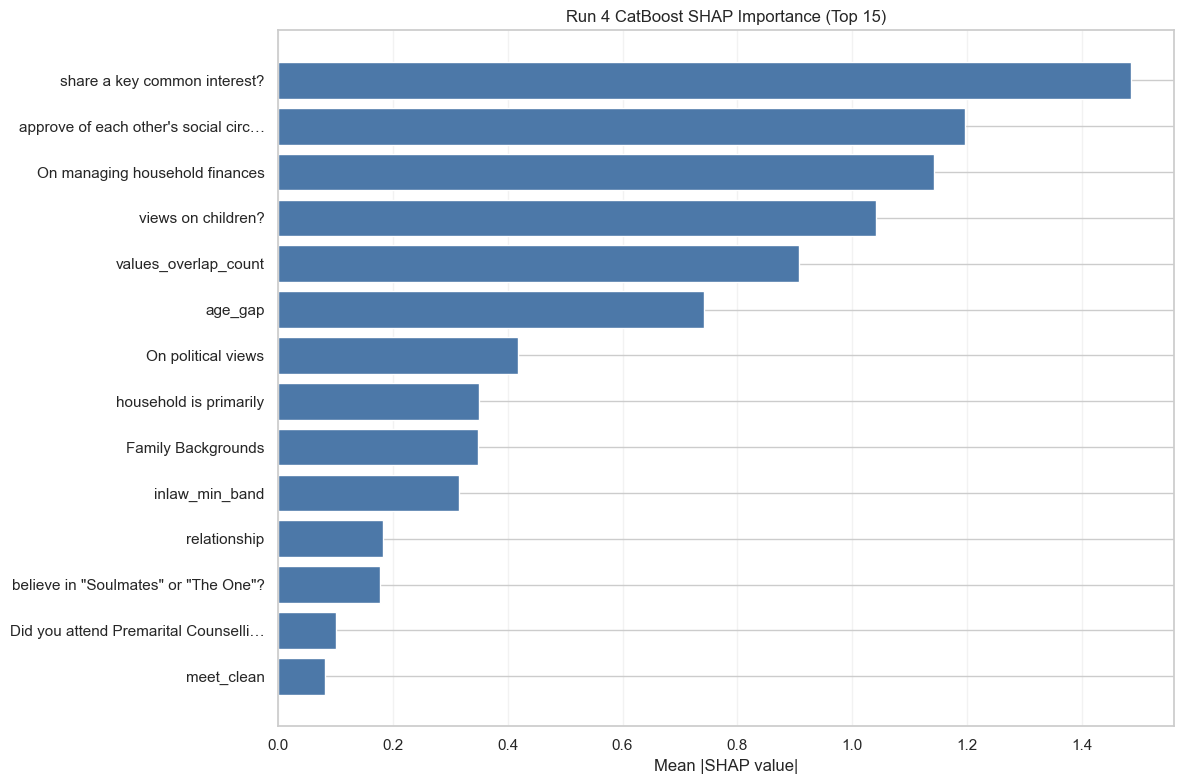

In [26]:
# SHAP (Shapley values) for Run 4 CatBoost model

if not HAS_CAT:
    raise RuntimeError("CatBoost is not available. Install catboost first.")

try:
    import shap
except Exception as e:
    raise RuntimeError("SHAP is not installed. Run: pip install shap") from e

# Refit Run 4 CatBoost on Run 4 transformed features
cat4_model = CatBoostClassifier(
    iterations=400, learning_rate=0.05, depth=6,
    loss_function="Logloss", verbose=0, random_seed=42
)

X4_tr_dense = X4_train_t.toarray() if hasattr(X4_train_t, "toarray") else X4_train_t
X4_te_dense = X4_test_t.toarray() if hasattr(X4_test_t, "toarray") else X4_test_t

cat4_model.fit(X4_tr_dense, y4_train)

# SHAP values
explainer = shap.TreeExplainer(cat4_model)
shap_values = explainer.shap_values(X4_te_dense)

# Binary-class handling
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # class 1 = Divorced/Annulled
else:
    shap_vals = shap_values

# Top transformed features by mean |SHAP|
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_imp_transformed = pd.DataFrame({
    "feature_transformed": feat4_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("=== Run 4 CatBoost SHAP (transformed features) ===")
display(shap_imp_transformed.head(20))

# Aggregate transformed -> original feature
cat4_sorted = sorted(cat4, key=len, reverse=True)

def _to_base_feature_run4_shap(tname):
    if tname.startswith("num__"):
        return tname.replace("num__", "", 1)
    if tname.startswith("cat__"):
        body = tname.replace("cat__", "", 1)
        for c in cat4_sorted:
            pref = c + "_"
            if body == c or body.startswith(pref):
                return c
        return body
    return tname

shap_imp_transformed["feature"] = shap_imp_transformed["feature_transformed"].apply(_to_base_feature_run4_shap)
shap_imp_base = (
    shap_imp_transformed.groupby("feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=== Run 4 CatBoost SHAP (original features, aggregated) ===")
display(shap_imp_base.head(20))

# Improved visibility plot: Top-N SHAP bars with shorter labels
top_n = 15
max_label_len = 36

plot_df = shap_imp_base.head(top_n).copy()

def _shorten_label(s, max_len=max_label_len):
    s = str(s).replace("Do you ", "").replace("What were your ", "")
    s = s.replace("Our ", "").replace("How long was your ", "")
    s = s.replace(" before marriage?", "").replace(" prior to the wedding?", "")
    s = s.replace(":", "")
    return s if len(s) <= max_len else s[: max_len - 1] + "…"

plot_df["feature_short"] = plot_df["feature"].apply(_shorten_label)

plt.figure(figsize=(12, 8))
plt.barh(
    y=plot_df["feature_short"][::-1],
    width=plot_df["mean_abs_shap"][::-1],
    height=0.8,
    color="#4C78A8"
 )
plt.xlabel("Mean |SHAP value|")
plt.ylabel("")
plt.title(f"Run 4 CatBoost SHAP Importance (Top {top_n})")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

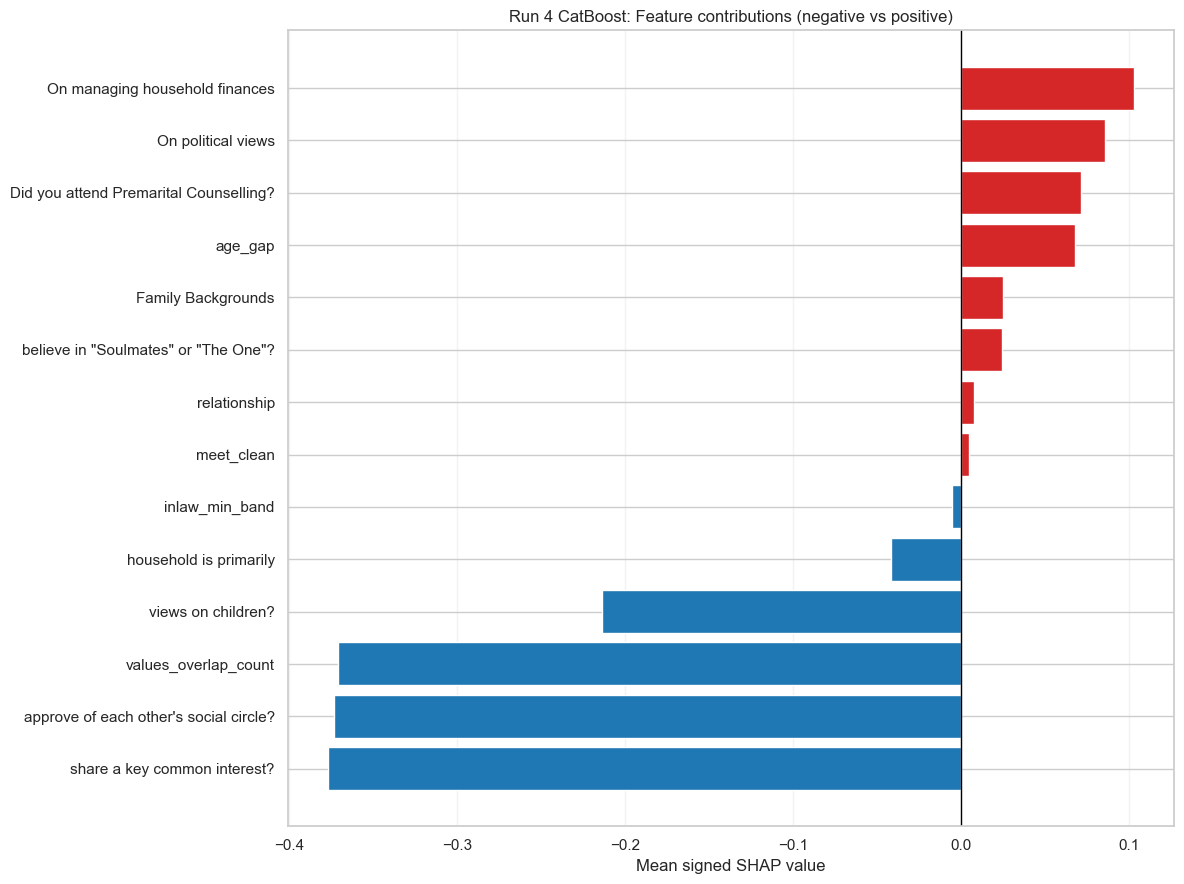

Interpretation: positive bars increase predicted probability of Divorced/Annulled; negative bars decrease it.


In [27]:
# Signed SHAP contribution chart (positive vs negative impact on divorce prediction)
if "shap_vals" not in globals():
    raise RuntimeError("Run the SHAP cell first so `shap_vals` is available.")

# Mean signed SHAP by transformed feature
mean_signed_shap = shap_vals.mean(axis=0)
signed_df = pd.DataFrame({
    "feature_transformed": feat4_names,
    "mean_signed_shap": mean_signed_shap
})

# Aggregate transformed -> original feature
cat4_sorted = sorted(cat4, key=len, reverse=True)

def _to_base_feature_signed(tname):
    if tname.startswith("num__"):
        return tname.replace("num__", "", 1)
    if tname.startswith("cat__"):
        body = tname.replace("cat__", "", 1)
        for c in cat4_sorted:
            pref = c + "_"
            if body == c or body.startswith(pref):
                return c
        return body
    return tname

signed_df["feature"] = signed_df["feature_transformed"].apply(_to_base_feature_signed)
signed_base = (
    signed_df.groupby("feature", as_index=False)["mean_signed_shap"]
    .sum()
    .sort_values("mean_signed_shap")
    .reset_index(drop=True)
)

# Keep top features by absolute signed impact for readability
top_n_signed = 20
plot_signed = signed_base.reindex(
    signed_base["mean_signed_shap"].abs().sort_values(ascending=False).index
).head(top_n_signed).sort_values("mean_signed_shap")

def _shorten_label_signed(s, max_len=40):
    s = str(s).replace("Do you ", "").replace("What were your ", "")
    s = s.replace("Our ", "").replace("How long was your ", "")
    s = s.replace(" before marriage?", "").replace(" prior to the wedding?", "")
    s = s.replace(":", "")
    return s if len(s) <= max_len else s[: max_len - 1] + "…"

plot_signed["feature_short"] = plot_signed["feature"].apply(_shorten_label_signed)
colors = np.where(plot_signed["mean_signed_shap"] >= 0, "#D62728", "#1F77B4")

plt.figure(figsize=(12, 9))
plt.barh(
    y=plot_signed["feature_short"],
    width=plot_signed["mean_signed_shap"],
    color=colors,
    height=0.82
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean signed SHAP value")
plt.ylabel("")
plt.title("Run 4 CatBoost: Feature contributions (negative vs positive)")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

print("Interpretation: positive bars increase predicted probability of Divorced/Annulled; negative bars decrease it.")

### 6.1 Feature Importance — Run 4 CatBoost
This ranks features by CatBoost’s built-in importance (gain-based) and plots the top contributors as a bar chart.

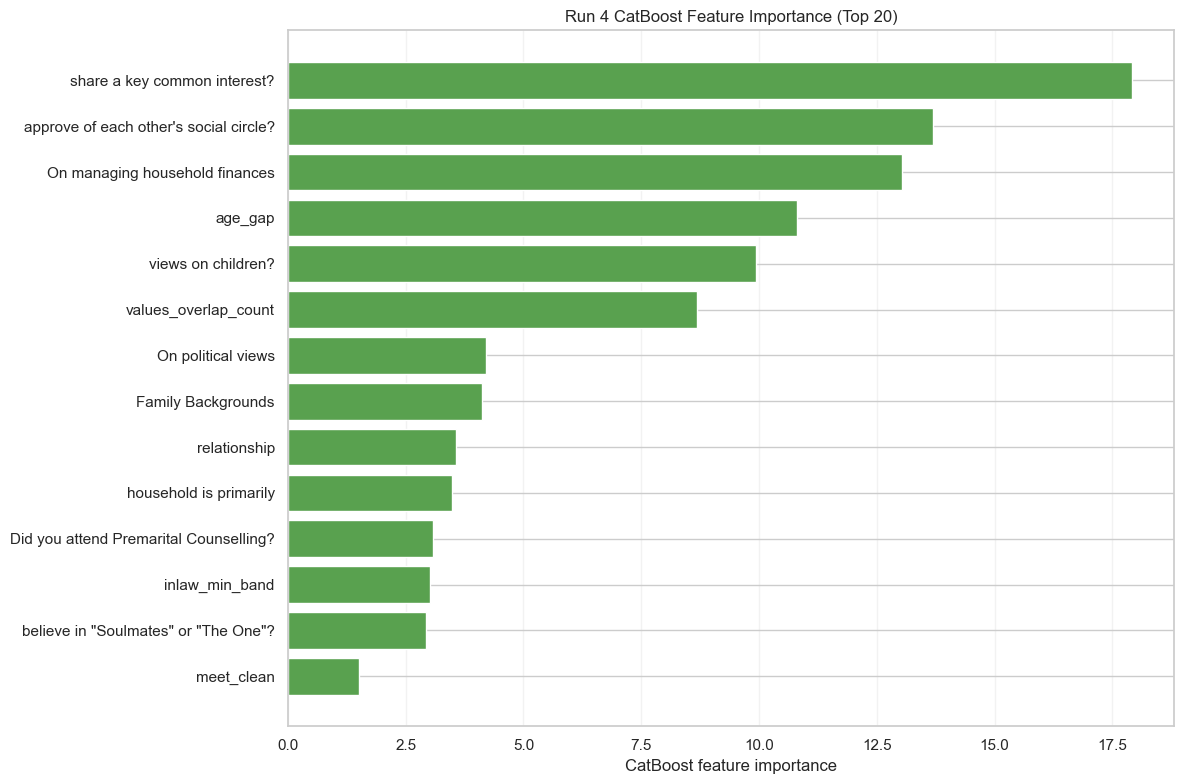

In [28]:
# Feature importance (CatBoost) on Run 4
if "cat4_model" not in globals():
    raise RuntimeError("Run the Run 4 CatBoost training cell first so `cat4_model` is available.")
if "feat4_names" not in globals():
    raise RuntimeError("Run the SHAP prep cell so `feat4_names` is available.")

# Raw importances at transformed feature level
try:
    importances = cat4_model.get_feature_importance()
except Exception:
    importances = cat4_model.get_feature_importance(type="FeatureImportance")

imp_df = pd.DataFrame({
    "feature_transformed": feat4_names,
    "importance": importances
})

# Aggregate transformed -> original feature
cat4_sorted = sorted(cat4, key=len, reverse=True)

def _to_base_feature_imp(tname):
    if tname.startswith("num__"):
        return tname.replace("num__", "", 1)
    if tname.startswith("cat__"):
        body = tname.replace("cat__", "", 1)
        for c in cat4_sorted:
            pref = c + "_"
            if body == c or body.startswith(pref):
                return c
        return body
    return tname

imp_df["feature"] = imp_df["feature_transformed"].apply(_to_base_feature_imp)
base_imp = (
    imp_df.groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

# Plot top features
top_n = 20
plot_imp = base_imp.head(top_n).copy()

def _shorten_label_imp(s, max_len=40):
    s = str(s).replace("Do you ", "").replace("What were your ", "")
    s = s.replace("Our ", "").replace("How long was your ", "")
    s = s.replace(" before marriage?", "").replace(" prior to the wedding?", "")
    s = s.replace(":", "")
    return s if len(s) <= max_len else s[: max_len - 1] + "…"

plot_imp["feature_short"] = plot_imp["feature"].apply(_shorten_label_imp)

plt.figure(figsize=(12, 8))
plt.barh(
    y=plot_imp["feature_short"][::-1],
    width=plot_imp["importance"][::-1],
    height=0.8,
    color="#59A14F"
)
plt.xlabel("CatBoost feature importance")
plt.ylabel("")
plt.title(f"Run 4 CatBoost Feature Importance (Top {top_n})")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 6.2 SHAP (Shapley) Interpretation — Run 4 CatBoost

#### What this chart means
- The x-axis is **mean signed SHAP value** for each feature.
- **Positive (red) bars**: on average, this feature pushes prediction toward **Divorced or Annulled**.
- **Negative (blue) bars**: on average, this feature pushes prediction toward **Married or Widowed**.
- Larger absolute bar length means stronger contribution to model output.

#### How to read top features
1. Identify the top 3–5 features by absolute bar length.
2. For each feature, note the sign:
   - Positive: associated with higher divorce prediction in this model.
   - Negative: associated with lower divorce prediction in this model.
3. Compare with domain logic (EDA findings) to check if direction is sensible.

#### Important caveats
- SHAP explains this **trained model**, not causal truth.
- Effects are conditional on other included features and their encodings.
- Correlated features can split importance across each other.
- Signed mean SHAP can hide subgroup effects; check dependence plots for deeper detail.

#### Summary
"In the Run 4 CatBoost model, the strongest contributors were **Sharing a key common interest**, **Approval of Social Circle**, and **Overlapping Personal Values**. Positive SHAP contributions increased the model’s probability of predicting divorced outcomes, while negative contributions shifted predictions toward married outcomes."

#### 6.2.1 SHAP deep-dive by response values
The next cells move from feature-level SHAP to response-level analysis.

They answer:
- Which specific answer choices push predictions most toward each class?
- Are those effects supported by enough observations (`n`)?
- Do directions align with descriptive divorce rates?

=== Top SHAP drivers by class direction (Run 4 CatBoost) ===


,direction,feature,mean_signed_shap,mean_abs_shap,n_transformed_cols
0,Toward Divorced/Annulled,On managing household finances:,0.102761,1.078111,3
1,Toward Divorced/Annulled,On political views:,0.085799,0.315977,4
2,Toward Divorced/Annulled,Did you attend Premarital Counselling?,0.071411,0.100673,2
3,Toward Married/Widowed,Do you share a key common interest?,-0.376908,1.485596,2
4,Toward Married/Widowed,Do you approve of each other's social circle?,-0.373380,0.829944,3
5,Toward Married/Widowed,values_overlap_count,-0.371099,0.907090,1


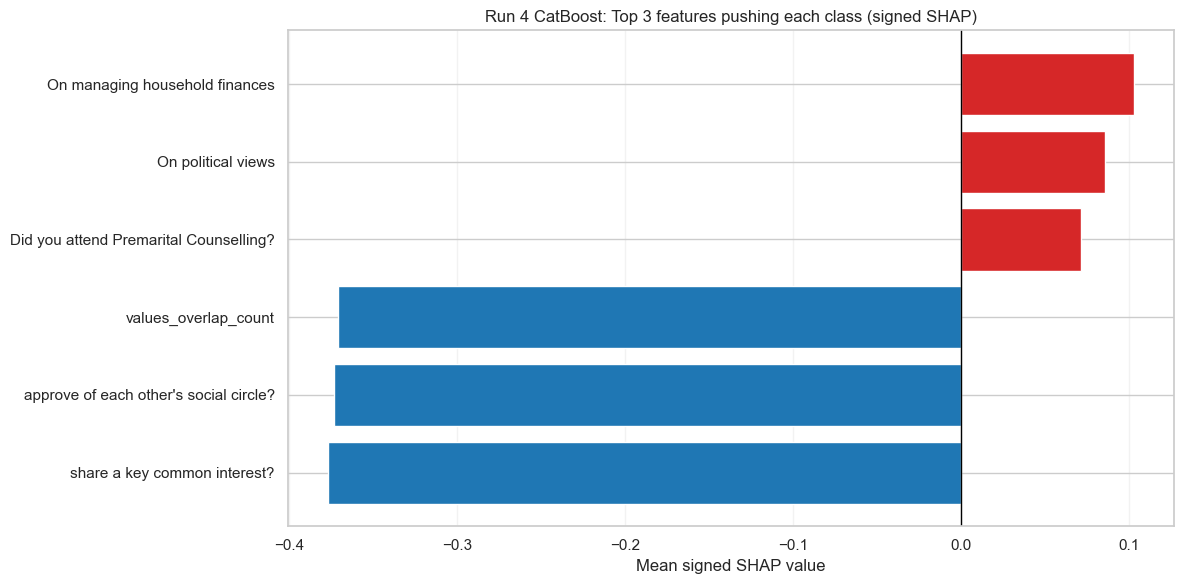

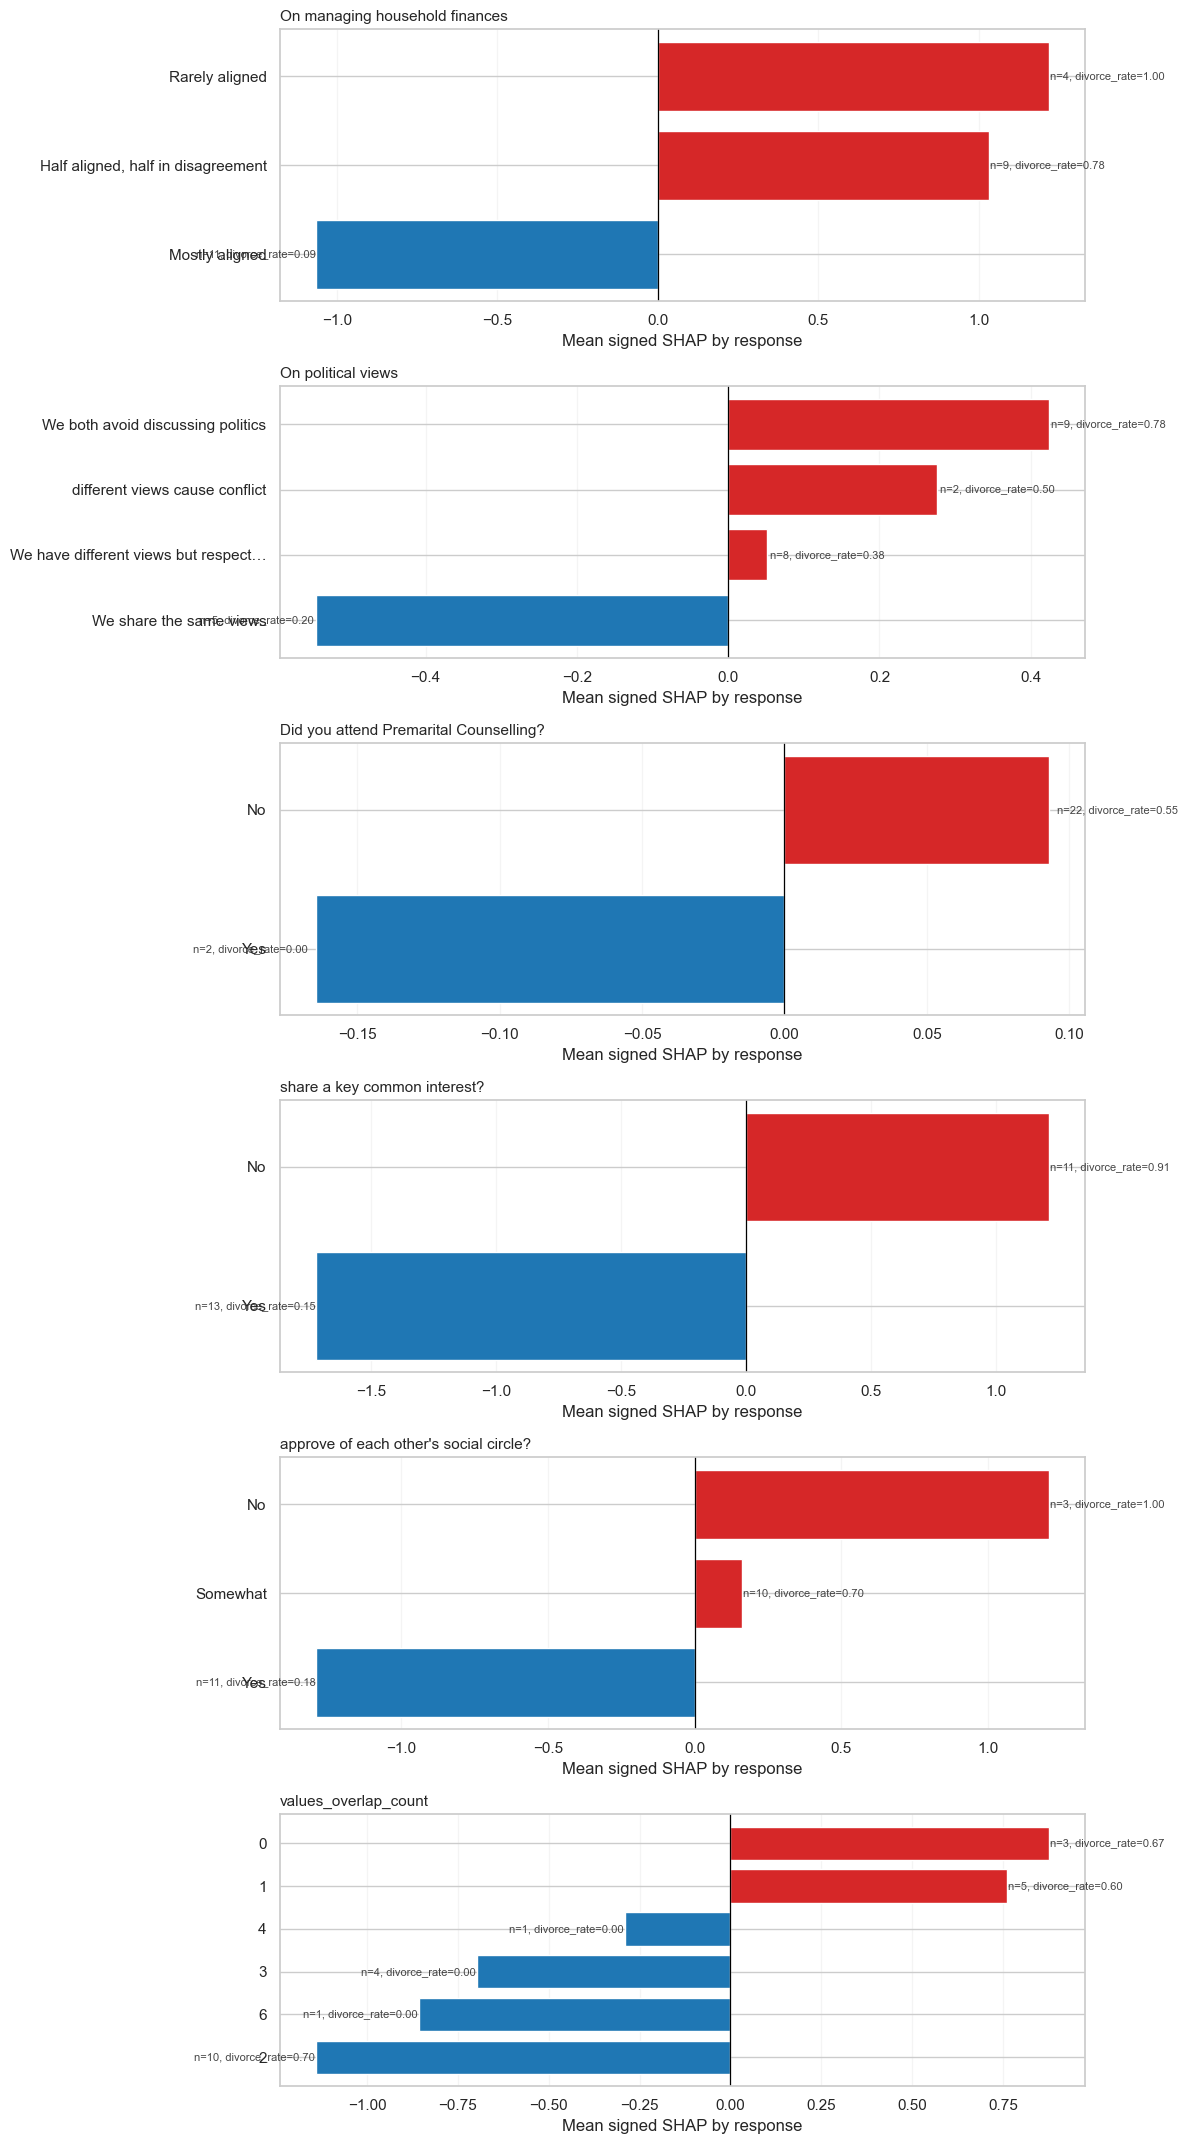


=== Response-level interpretation helper ===
- On managing household finances:
  Most toward Divorced/Annulled: 'Rarely aligned' (mean SHAP=1.2186, divorce_rate=1.00)
  Most toward Married/Widowed: 'Mostly aligned' (mean SHAP=-1.0640, divorce_rate=0.09)
- On political views:
  Most toward Divorced/Annulled: 'We both avoid discussing politics' (mean SHAP=0.4238, divorce_rate=0.78)
  Most toward Married/Widowed: 'We share the same views' (mean SHAP=-0.5444, divorce_rate=0.20)
- Did you attend Premarital Counselling?
  Most toward Divorced/Annulled: 'No' (mean SHAP=0.0928, divorce_rate=0.55)
  Most toward Married/Widowed: 'Yes' (mean SHAP=-0.1643, divorce_rate=0.00)
- Do you share a key common interest?
  Most toward Divorced/Annulled: 'No' (mean SHAP=1.2095, divorce_rate=0.91)
  Most toward Married/Widowed: 'Yes' (mean SHAP=-1.7192, divorce_rate=0.15)
- Do you approve of each other's social circle?
  Most toward Divorced/Annulled: 'No' (mean SHAP=1.2080, divorce_rate=1.00)
  Most toward

In [37]:
# SHAP deep-dive: top 3 features toward each class + response-level effects
if "shap_vals" not in globals():
    raise RuntimeError("Run the SHAP cell first so `shap_vals` is available.")

# Build row-level SHAP frame at transformed-feature level
shap_trans_df = pd.DataFrame(shap_vals, columns=feat4_names, index=X4_test.index)

def _transformed_cols_for_base(base_feature):
    num_col = f"num__{base_feature}"
    cat_col = f"cat__{base_feature}"
    cat_prefix = f"cat__{base_feature}_"
    cols = [c for c in shap_trans_df.columns if c == num_col or c == cat_col or c.startswith(cat_prefix)]
    return cols

# Compute mean signed SHAP per original Run 4 feature
base_signed_rows = []
for f in feature_cols_run4:
    cols_f = _transformed_cols_for_base(f)
    if len(cols_f) == 0:
        continue
    row_contrib = shap_trans_df[cols_f].sum(axis=1)
    base_signed_rows.append({
        "feature": f,
        "mean_signed_shap": row_contrib.mean(),
        "mean_abs_shap": row_contrib.abs().mean(),
        "n_transformed_cols": len(cols_f)
    })

base_signed_df = pd.DataFrame(base_signed_rows).sort_values("mean_signed_shap")
if base_signed_df.empty:
    raise RuntimeError("No SHAP contributions mapped to Run 4 base features.")

top3_divorce = base_signed_df.nlargest(3, "mean_signed_shap")
top3_married = base_signed_df.nsmallest(3, "mean_signed_shap")

summary_top = pd.concat([
    top3_divorce.assign(direction="Toward Divorced/Annulled"),
    top3_married.assign(direction="Toward Married/Widowed")
]).reset_index(drop=True)

print("=== Top SHAP drivers by class direction (Run 4 CatBoost) ===")
display(summary_top[["direction", "feature", "mean_signed_shap", "mean_abs_shap", "n_transformed_cols"]])

# Chart 1: top 3 toward each class (signed)
plot_rank = pd.concat([top3_married, top3_divorce]).copy()
plot_rank = plot_rank.sort_values("mean_signed_shap")

def _short_name(s, max_len=42):
    s = str(s).replace("Do you ", "").replace("What were your ", "")
    s = s.replace("Our ", "").replace("How long was your ", "")
    s = s.replace(" before marriage?", "").replace(" prior to the wedding?", "")
    s = s.replace(":", "")
    return s if len(s) <= max_len else s[:max_len - 1] + "…"

plot_rank["feature_short"] = plot_rank["feature"].apply(_short_name)
colors = np.where(plot_rank["mean_signed_shap"] >= 0, "#D62728", "#1F77B4")

plt.figure(figsize=(12, 6))
plt.barh(
    y=plot_rank["feature_short"],
    width=plot_rank["mean_signed_shap"],
    color=colors,
    height=0.8
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Run 4 CatBoost: Top 3 features pushing each class (signed SHAP)")
plt.xlabel("Mean signed SHAP value")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Response-level analysis for those 6 features
selected_features = list(dict.fromkeys(list(top3_divorce["feature"]) + list(top3_married["feature"])))
response_tables = {}

for f in selected_features:
    cols_f = _transformed_cols_for_base(f)
    row_contrib = shap_trans_df[cols_f].sum(axis=1)

    temp = pd.DataFrame({
        "response": X4_test[f].astype(str).fillna("Missing"),
        "row_shap": row_contrib,
        "target": y4_test.values
    })
    grp = (
        temp.groupby("response", as_index=False)
        .agg(
            n=("response", "size"),
            mean_signed_shap=("row_shap", "mean"),
            mean_abs_shap=("row_shap", lambda x: np.mean(np.abs(x))),
            divorce_rate=("target", "mean")
        )
        .sort_values("n", ascending=False)
    )
    grp["divorce_rate"] = grp["divorce_rate"].round(3)
    response_tables[f] = grp

# Chart 2: small multiples by feature response (mean signed SHAP by response)
n_feat = len(selected_features)
fig, axes = plt.subplots(nrows=n_feat, ncols=1, figsize=(12, 3.6 * n_feat))
if n_feat == 1:
    axes = [axes]

for ax, f in zip(axes, selected_features):
    g = response_tables[f].copy()
    g = g.sort_values("mean_signed_shap")  # show all response values
    g["response_short"] = g["response"].apply(lambda s: _short_name(s, max_len=36))
    bar_colors = np.where(g["mean_signed_shap"] >= 0, "#D62728", "#1F77B4")

    ax.barh(g["response_short"], g["mean_signed_shap"], color=bar_colors, height=0.78)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_title(_short_name(f, max_len=70), fontsize=11, loc="left")
    ax.set_xlabel("Mean signed SHAP by response")
    ax.grid(axis="x", alpha=0.2)

    # annotate with n and divorce rate
    for y_pos, (_, r) in enumerate(g.iterrows()):
        txt = f"n={int(r['n'])}, divorce_rate={r['divorce_rate']:.2f}"
        x_val = r["mean_signed_shap"]
        pad = 0.003 if x_val >= 0 else -0.003
        ha = "left" if x_val >= 0 else "right"
        ax.text(x_val + pad, y_pos, txt, va="center", ha=ha, fontsize=8, alpha=0.85)

plt.tight_layout()
plt.show()

# Printed interpretation helper
print("\n=== Response-level interpretation helper ===")
for f in selected_features:
    g = response_tables[f]
    top_pos = g.sort_values("mean_signed_shap", ascending=False).head(1)
    top_neg = g.sort_values("mean_signed_shap", ascending=True).head(1)
    p_resp = top_pos.iloc[0]["response"]
    p_val = top_pos.iloc[0]["mean_signed_shap"]
    p_rate = top_pos.iloc[0]["divorce_rate"]
    n_resp = top_neg.iloc[0]["response"]
    n_val = top_neg.iloc[0]["mean_signed_shap"]
    n_rate = top_neg.iloc[0]["divorce_rate"]
    print(f"- {f}")
    print(f"  Most toward Divorced/Annulled: '{p_resp}' (mean SHAP={p_val:.4f}, divorce_rate={p_rate:.2f})")
    print(f"  Most toward Married/Widowed: '{n_resp}' (mean SHAP={n_val:.4f}, divorce_rate={n_rate:.2f})")

Fold 1 done: valid rows=24
Fold 2 done: valid rows=24
Fold 3 done: valid rows=24
Fold 4 done: valid rows=24
Fold 5 done: valid rows=24
=== OOF SHAP top drivers by class direction ===


,direction,feature,mean_signed_shap,mean_abs_shap
0,Toward Divorced/Annulled,On managing household finances:,0.101506,1.709113
1,Toward Divorced/Annulled,age_gap,0.055482,0.763386
2,Toward Divorced/Annulled,values_overlap_count,0.042899,0.452797
3,Toward Married/Widowed,Do you approve of each other's social circle?,-0.036426,1.017859
4,Toward Married/Widowed,What were your views on children?,-0.020613,0.447264
5,Toward Married/Widowed,Do you share a key common interest?,-0.014721,1.293151


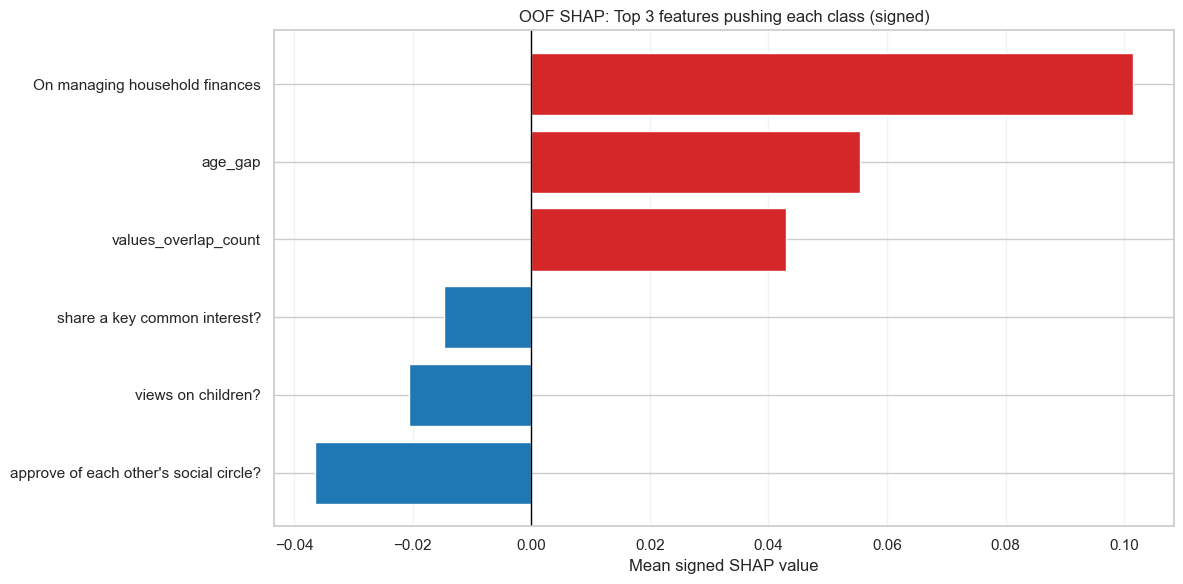

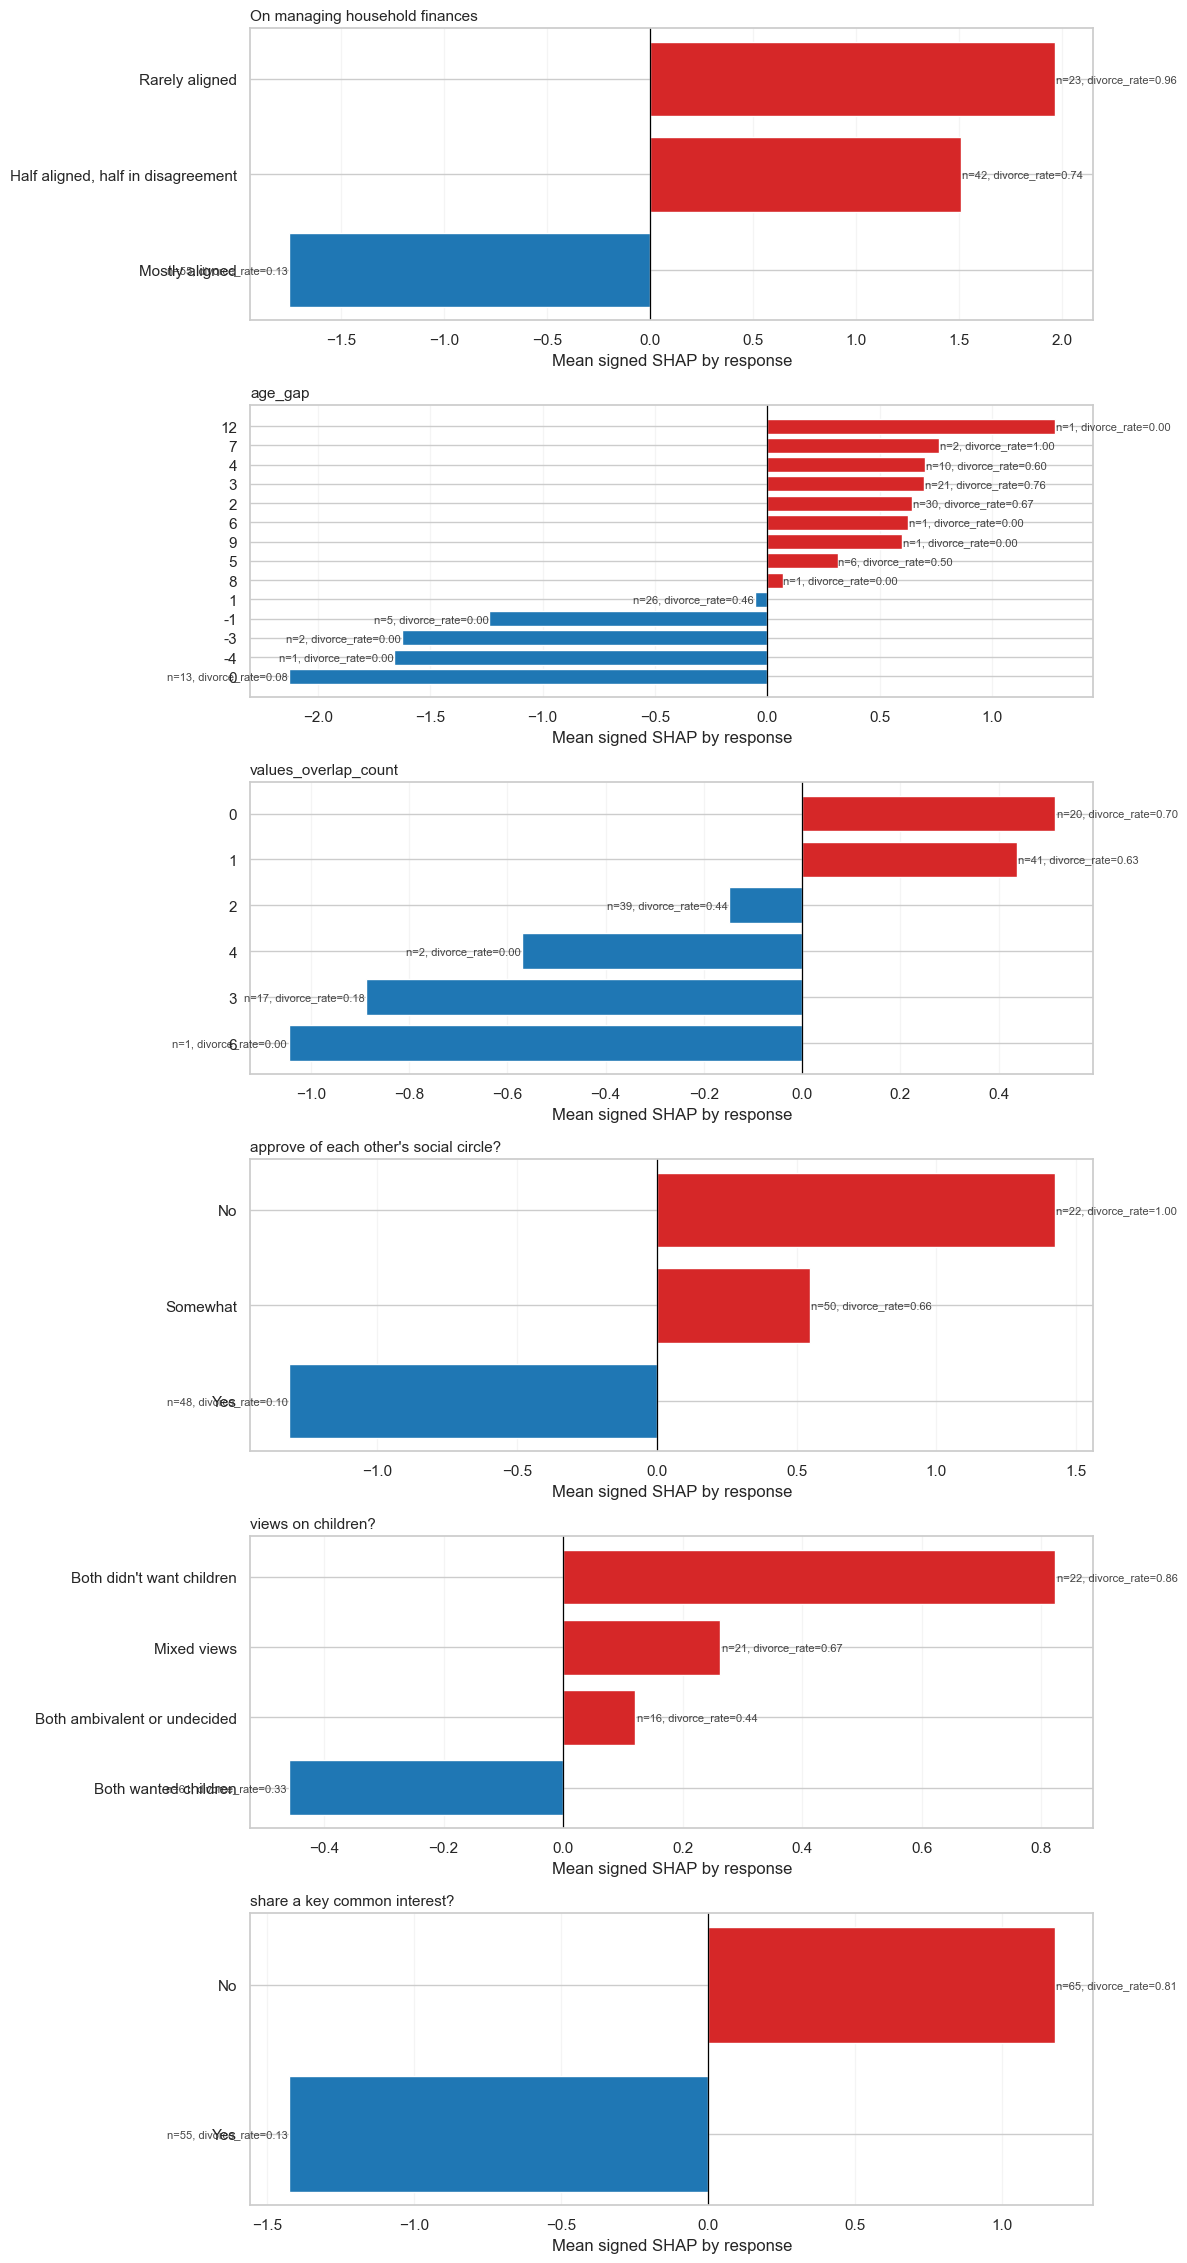

Total eligible rows used in OOF SHAP: 120
On managing household finances:: sum(n)=120
age_gap: sum(n)=120
values_overlap_count: sum(n)=120
Do you approve of each other's social circle?: sum(n)=120
What were your views on children?: sum(n)=120
Do you share a key common interest?: sum(n)=120


In [30]:
# OOF SHAP deep-dive (Option 2): cross-validated, near-full-row explanations
# Replace your current SHAP deep-dive cell with this.

if not HAS_CAT:
    raise RuntimeError("CatBoost is not available. Install catboost first.")

# Ensure Run 4 objects exist
required = ["X4", "y4", "feature_cols_run4", "num4", "cat4"]
missing_req = [v for v in required if v not in globals()]
if missing_req:
    raise RuntimeError(f"Run 4 cell first. Missing: {missing_req}")

# Container: row-level OOF SHAP contributions at BASE feature level
oof_base_shap = pd.DataFrame(index=X4.index, columns=feature_cols_run4, dtype=float)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, va_idx) in enumerate(cv.split(X4, y4), start=1):
    X_tr, X_va = X4.iloc[tr_idx], X4.iloc[va_idx]
    y_tr = y4.iloc[tr_idx]

    pre_cv = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num4),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat4),
        ],
        remainder="drop"
    )

    X_tr_t = pre_cv.fit_transform(X_tr)
    X_va_t = pre_cv.transform(X_va)
    feat_cv = pre_cv.get_feature_names_out()

    X_tr_dense = X_tr_t.toarray() if hasattr(X_tr_t, "toarray") else X_tr_t
    X_va_dense = X_va_t.toarray() if hasattr(X_va_t, "toarray") else X_va_t

    model = CatBoostClassifier(
        iterations=400, learning_rate=0.05, depth=6,
        loss_function="Logloss", verbose=0, random_seed=42
    )
    model.fit(X_tr_dense, y_tr)

    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_va_dense)
    sv = sv[1] if isinstance(sv, list) else sv  # class 1 = Divorced/Annulled

    shap_trans_fold = pd.DataFrame(sv, columns=feat_cv, index=X_va.index)

    # Fold transformed -> base feature aggregation
    for f in feature_cols_run4:
        num_col = f"num__{f}"
        cat_col = f"cat__{f}"
        cat_prefix = f"cat__{f}_"
        cols_f = [c for c in shap_trans_fold.columns if c == num_col or c == cat_col or c.startswith(cat_prefix)]
        if len(cols_f) == 0:
            continue
        oof_base_shap.loc[X_va.index, f] = shap_trans_fold[cols_f].sum(axis=1).values

    print(f"Fold {fold} done: valid rows={len(X_va)}")

# Safety check
if oof_base_shap.isna().all(axis=1).any():
    bad_rows = int(oof_base_shap.isna().all(axis=1).sum())
    raise RuntimeError(f"{bad_rows} rows have no OOF SHAP values. Check preprocessing mapping.")

# 1) Top-3 features toward each class (using full OOF rows)
base_signed_df = pd.DataFrame({
    "feature": feature_cols_run4,
    "mean_signed_shap": oof_base_shap.mean(axis=0).values,
    "mean_abs_shap": oof_base_shap.abs().mean(axis=0).values
}).sort_values("mean_signed_shap")

top3_divorce = base_signed_df.nlargest(3, "mean_signed_shap")
top3_married = base_signed_df.nsmallest(3, "mean_signed_shap")

summary_top = pd.concat([
    top3_divorce.assign(direction="Toward Divorced/Annulled"),
    top3_married.assign(direction="Toward Married/Widowed")
], ignore_index=True)

print("=== OOF SHAP top drivers by class direction ===")
display(summary_top[["direction", "feature", "mean_signed_shap", "mean_abs_shap"]])

# Plot helper
def _short_name(s, max_len=42):
    s = str(s).replace("Do you ", "").replace("What were your ", "")
    s = s.replace("Our ", "").replace("How long was your ", "")
    s = s.replace(" before marriage?", "").replace(" prior to the wedding?", "")
    s = s.replace(":", "")
    return s if len(s) <= max_len else s[:max_len - 1] + "…"

# Chart 1
plot_rank = pd.concat([top3_married, top3_divorce]).sort_values("mean_signed_shap").copy()
plot_rank["feature_short"] = plot_rank["feature"].apply(_short_name)
colors = np.where(plot_rank["mean_signed_shap"] >= 0, "#D62728", "#1F77B4")

plt.figure(figsize=(12, 6))
plt.barh(plot_rank["feature_short"], plot_rank["mean_signed_shap"], color=colors, height=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.title("OOF SHAP: Top 3 features pushing each class (signed)")
plt.xlabel("Mean signed SHAP value")
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Response-level effects for those 6 features (ALL responses shown, no top-k cut)
selected_features = list(dict.fromkeys(list(top3_divorce["feature"]) + list(top3_married["feature"])))
response_tables = {}

for f in selected_features:
    temp = pd.DataFrame({
        "response": X4[f].astype(str).fillna("Missing"),
        "row_shap": oof_base_shap[f].values,
        "target": y4.values
    })
    grp = (
        temp.groupby("response", as_index=False)
        .agg(
            n=("response", "size"),
            mean_signed_shap=("row_shap", "mean"),
            mean_abs_shap=("row_shap", lambda x: np.mean(np.abs(x))),
            divorce_rate=("target", "mean")
        )
        .sort_values("mean_signed_shap")
    )
    grp["divorce_rate"] = grp["divorce_rate"].round(3)
    response_tables[f] = grp

n_feat = len(selected_features)
fig, axes = plt.subplots(nrows=n_feat, ncols=1, figsize=(12, 3.8 * n_feat))
if n_feat == 1:
    axes = [axes]

for ax, f in zip(axes, selected_features):
    g = response_tables[f].copy()  # ALL values included
    g["response_short"] = g["response"].apply(lambda s: _short_name(s, max_len=36))
    bar_colors = np.where(g["mean_signed_shap"] >= 0, "#D62728", "#1F77B4")

    ax.barh(g["response_short"], g["mean_signed_shap"], color=bar_colors, height=0.78)
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_title(_short_name(f, max_len=70), fontsize=11, loc="left")
    ax.set_xlabel("Mean signed SHAP by response")
    ax.grid(axis="x", alpha=0.2)

    for y_pos, (_, r) in enumerate(g.iterrows()):
        txt = f"n={int(r['n'])}, divorce_rate={r['divorce_rate']:.2f}"
        x_val = r["mean_signed_shap"]
        pad = 0.003 if x_val >= 0 else -0.003
        ha = "left" if x_val >= 0 else "right"
        ax.text(x_val + pad, y_pos, txt, va="center", ha=ha, fontsize=8, alpha=0.85)

plt.tight_layout()
plt.show()

# Quick sanity: n totals should now match full eligible rows per feature
print(f"Total eligible rows used in OOF SHAP: {len(X4)}")
for f in selected_features:
    print(f"{f}: sum(n)={int(response_tables[f]['n'].sum())}")

In [31]:
# Pull n from latest SHAP response tables (or fallback to X4 counts)

targets = [
    ("What were your views on children?", "Both wanted children"),
    ("On managing household finances:", "Mostly aligned"),
]

for feature, response_text in targets:
    print(f"\nFeature: {feature}")
    
    # 1) Try SHAP response_tables first
    if "response_tables" in globals() and feature in response_tables:
        g = response_tables[feature].copy()
        exact = g[g["response"].str.strip().str.lower() == response_text.strip().lower()]
        if len(exact):
            print(f"SHAP n ({response_text}):", int(exact["n"].iloc[0]))
        else:
            # show close matches
            close = g[g["response"].str.lower().str.contains(response_text.lower(), na=False)][["response", "n"]]
            if len(close):
                print("No exact match. Close SHAP matches:")
                display(close)
            else:
                print("Response not found in SHAP response table for this feature.")
    else:
        print("Feature not present in current response_tables (not in top-6 SHAP deep-dive set).")

    # 2) Fallback raw count from X4 (should match SHAP group count basis)
    if "X4" in globals() and feature in X4.columns:
        raw_counts = X4[feature].astype(str).value_counts(dropna=False)
        raw_exact = raw_counts[raw_counts.index.str.strip().str.lower() == response_text.strip().lower()]
        if len(raw_exact):
            print(f"Raw X4 n ({response_text}):", int(raw_exact.iloc[0]))
        else:
            close_idx = [idx for idx in raw_counts.index if response_text.lower() in idx.lower()]
            if close_idx:
                print("No exact raw match. Close raw matches:")
                display(raw_counts.loc[close_idx].rename_axis("response").reset_index(name="n"))
            else:
                print("Response not found in X4 for this feature.")


Feature: What were your views on children?
SHAP n (Both wanted children): 61
Raw X4 n (Both wanted children): 61

Feature: On managing household finances:
SHAP n (Mostly aligned): 55
Raw X4 n (Mostly aligned): 55


# 7. Results Summary

## 7.1 Key findings (Run 4 CatBoost)
The best-performing configuration in this notebook is **Run 4 with CatBoost**. It achieved strong test performance (Accuracy **0.9583**, F1 **0.9565**) with a modest train–test gap (**0.0417**), suggesting the model is capturing meaningful patterns without severe overfitting.

From the model’s importance and SHAP explanations, the most influential themes are:
- **Shared interests and values** (e.g., key common interest, values overlap): alignment appears consistently protective.
- **Social environment alignment** (approval of each other’s social circle): disagreement here is a strong risk signal.
- **Relationship dynamics and expectations** (e.g., views on children, finances, or marriage-related expectations depending on the feature set): mismatches in core life plans amplify predicted risk.

In plain terms, the model is most sensitive to **alignment on fundamentals** (values, social support, life goals) rather than a single demographic factor. This aligns with the EDA findings that the *quality of alignment* across multiple domains is more predictive than any one isolated variable.

## 7.2 Practical interpretation (non-causal)
These results are **associational**, not causal. The model is useful for identifying *risk clusters* rather than “causes of divorce.” It suggests that when couples diverge on fundamental priorities (values, social circles, or long‑term goals), the risk score increases. Conversely, strong alignment across these domains tends to lower predicted risk.

## 7.3 Actionable next steps for this topic
**For analytics and modelling**
- **Validate stability**: run repeated CV and report mean/variance for CatBoost Run 4 to confirm robustness.
- **Audit feature leakage**: confirm no post‑outcome variables are included in the feature set.
- **Segment analysis**: evaluate model performance by subgroup (e.g., relationship length, children status) to identify where predictions are less reliable.

**For program or intervention design**
- **Design alignment check‑ins**: create short, structured assessments around values, social circle expectations, and financial alignment early in relationships.
- **Targeted counseling modules**: offer focused sessions on the top risk domains (values, social approval, and future plans) rather than generic counseling.
- **Communication prompts**: build guided prompts or questionnaires for couples to surface disagreements in high‑impact areas.

**For research/measurement**
- **Collect more granular data** on alignment (e.g., finer‑grained values or decision‑making styles) to improve signal quality.
- **Track change over time**: longitudinal responses can reveal whether alignment improves and whether risk scores shift accordingly.


## 8. Model Export for Predictor Deployment

This section saves the best-performing model (**Run 4 CatBoost**) as a `.cbm` file so it can be exported and reused to build the predictor application.

- Model artifact: `catboost_run4_best_model.cbm`
- Purpose: portable CatBoost binary for downstream loading/inference

In [36]:
# Save best model (Run 4 CatBoost) to CBM for export
from pathlib import Path

# Output path includes both model type and run number
model_export_path = Path.cwd() / "catboost_run4_best_model.cbm"

# Save the fitted Run 4 CatBoost model
cat4_model.save_model(str(model_export_path), format="cbm")

# Quick check of feature set used by this model
print("Saved:", model_export_path)
print("Run 4 feature count:", len(feature_cols_run4))
print("Run 4 features:", feature_cols_run4)

Saved: /Users/clairesng/Downloads/capstone_divorced/catboost_run4_best_model.cbm
Run 4 feature count: 14
Run 4 features: ['age_gap', 'Our Family Backgrounds:', 'meet_clean', 'How long was your relationship before marriage?', 'Did you attend Premarital Counselling?', 'Do you believe in "Soulmates" or "The One"?', 'What were your views on children?', 'On political views:', 'inlaw_min_band', 'Our household is primarily:', 'On managing household finances:', 'Do you share a key common interest?', "Do you approve of each other's social circle?", 'values_overlap_count']
